# GridDividend — Virginia
## Dominion Energy Virginia: Shared Savings Reform Analysis

**Dr Robert A. F. Currie, 2026 — Virginia Extension**

*Parameters sourced from SCC Case PUR-2025-00058 (November 2025) and PJM BRA 2025. Six parameters require verification from SCC filing before results should be treated as final — see ⚠️ flags in Section 1.*

Companion model to: *GridDividend: A Model for Electric Utility Reform* (Substack, 2026)  
Based on: *Electric Utility Reform in an Age of Electrification* (The States Forum, 2025)  
Repository: github.com/robertafcurrie/GridDividend

---

The United States is at an inflection point in how it powers itself. Electricity demand is rising for the first time in decades, driven by electric vehicles, heat pumps, data centres, and industrial electrification. The grid that will carry this load is being built now — in rate cases, capital programmes, and regulatory decisions made state by state, utility by utility, year by year. The choices made in the next decade will compound for half a century. This is not primarily a crisis. It is an opportunity — one of the largest in the history of the American electric industry. States and utilities that move early to align financial incentives with efficient outcomes will build a cleaner, more resilient, and more affordable grid than the one the current regulatory model would produce. The window for states AND utilities to lead on this is open. GridDividend is a tool for exploring what leadership could look like in practice — not a finished answer, but a structured starting point for the conversations that need to happen.

### What this model is — and is not

GridDividend is a **strategic policy simulation framework**. It is designed to show the *direction and order of magnitude* of the shared savings opportunity using real regulatory starting parameters and transparent assumptions. It is **not** a utility planning model, a rate case filing, or a forecast.

Three specific scope boundaries matter most:

- **Full tariff bill, not all bill components.** The bill figures include both delivery (distribution infrastructure) and supply (energy and PJM capacity costs), anchored to filed tariff rates for a 1,000 kWh/month customer (Virginia SCC standard, set via residential_kwh_month in utility JSON). Shared savings reform acts primarily on the delivery component through infrastructure avoidance, and secondarily on supply through lower peak demand reducing PJM capacity obligations. What the model does not project are independent movements in wholesale energy prices, transmission costs, or policy surcharges — these are held at their starting growth trajectory. Reform savings represent what a distribution utility under shared savings incentives can influence, not a forecast of total electricity bill movements.
- **Spatially aggregate.** The model treats the grid as a system-wide pool of capacity. Real distribution systems are constrained networks where NWS value depends on *where* the DER is relative to *where* the constraint is. Individual feeders will see very different outcomes from the system average.
- **One representative scenario.** Results are a single deterministic trajectory, not a probability distribution. Many parameters are uncertain and correlated in ways the model does not capture.
- **AI assistance.** AI was used extensively in researching and creating this model, and in writing the companion article.

These limitations are discussed fully in Section 10.

### How to use this notebook

1. **Edit Section 1** to change any parameter
2. **Run All Cells** (Kernel → Restart & Run All)
3. Charts save to `charts_article/` folder

All bill figures are for a 1,000 kWh/month residential customer — the standard Virginia SCC benchmark (set via residential_kwh_month in utility JSON).  
Results cover 2026–2050. BAU = Business As Usual. SS = Shared Savings Reform.

---

## Section 0: Setup
Imports, styling, and output directory.

In [1]:
# ============================================================
# SECTION 0: SETUP
# Loads the model engine from ../engine/model.py and utility
# data from ../utilities/*.json — see CLAUDE.md architecture notes.
# Requires: pandas, numpy, matplotlib (all standard Anaconda/pip packages)
# Install if needed: pip install pandas numpy matplotlib
# ============================================================

import sys, os, subprocess
sys.path.insert(0, '..')
import json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from engine import project, run_named_scenario, apply_passthrough_savings

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})
C = {
    'bau': '#d62728', 'shared': '#2ca02c',
    'freeze_bau': '#ff7f0e', 'freeze_shared': '#17becf',
    'util_bau': '#ff7f0e', 'util_shared': '#1f77b4',
    'neutral': '#888888', 'tax': '#9467bd',
    'capex_spent': '#1f77b4', 'capex_avoided': '#2ca02c',
    'opex_nws': '#ff7f0e', 'ineligible': '#c5b0d5',
}
YEARS = list(range(2026, 2051))
os.makedirs('charts', exist_ok=True)

# ── Utility data (loaded from ../utilities/*.json) ────────────────────────────
#
# Sources: see ../utilities/Dominion_VA.json (_instructions field)
#   Dominion VA: SCC Case PUR-2025-00058 (biennial review, final order
#                November 2025, rates effective January 2026 and January 2027)
#                PJM BRA reports 2025; Dominion 10-K 2025; Schedule 1 tariff Jan 2026
#                ⚠ Six parameters are estimated and flagged _VERIFY in the JSON —
#                  see the warning cell after Section 1.

DomVA_params = json.load(open('../utilities/Dominion_VA.json'))
UTILITIES = {'DomVA': DomVA_params}

# Shared parameters applying to both utilities
SHARED_DEFAULTS = {
    "ev_adoption_curve": {
        # Virginia EV registration projections
        # Source: Virginia DEQ ZEV programme; Dominion 2024 IRP EV forecast
        # Virginia has ~130,000 EVs registered in 2024 (lower density than NY)
        2026:   150_000,
        2030:   500_000,
        2035: 1_200_000,
        2040: 2_000_000,
        2050: 3_000_000,
    },
    "ev_peak_kw": 7.2,       # Average peak draw per EV (Level 2 charging, kW)
}

print("GridDividend v1.0 — modular engine (engine/model.py) + JSON utility data.")
print(f"Modelling years: {YEARS[0]}–{YEARS[-1]}")
print(f"Charts → charts/")
print()
print("Utilities loaded:")
for k, u in UTILITIES.items():
    print(f"  {u['short_name']} ({u['filing_case']})")


GridDividend v1.0 — modular engine (engine/model.py) + JSON utility data.
Modelling years: 2026–2050
Charts → charts/

Utilities loaded:
  Dominion VA (SCC Case PUR-2025-00058 (biennial review, final order November 2025, rates effective January 2026 and January 2027))


## Section 1: Parameters

**Edit any value here. Then re-run all cells.**

All parameters are documented with their sources and rationale.
See the companion article for full discussion of each assumption.

In [2]:
# ============================================================
# SECTION 1: USER-ADJUSTABLE PARAMETERS
# ============================================================

# ── Utilities to model ────────────────────────────────────────────────────────
utilities_to_run = ['DomVA']   # Dominion Energy Virginia

# ── Shared savings mechanism ──────────────────────────────────────────────────
UTILITY_SAVINGS_SHARE = 0.30
# Fraction of savings pool retained by utility. Default 30%.
# Based on NY PSC precedent for NWS incentive mechanisms.
# Remainder (70%) is returned to customers as bill savings.

# ── NWS-eligible CAPEX ────────────────────────────────────────────────────────
NWS_ELIGIBLE_CAPEX_SHARE_START = 0.30
# Starting fraction of annual CAPEX addressable by NWS (~30%).
# Consistent with proportion of Con Ed rate case increase driven by
# new infrastructure investment. Brattle Ontario study found 20-40%
# growth capex reduction at provincial scale — consistent with this range.

NWS_ELIGIBLE_CAPEX_SHARE_MAX = 0.50
# Maximum eligible share as electrification drives more load-growth CAPEX.
# Ceiling reflects that asset replacement never disappears from the programme.

NWS_ELIGIBLE_CAPEX_LOAD_SENSITIVITY = 2.0
# Rate at which eligible share grows with cumulative electrification load.

NWS_AVOIDANCE_OF_ELIGIBLE_START = 0.20
# Fraction of eligible CAPEX NWS defers in year 1.
# Low in early years: programmes nascent, DER aggregation immature.

NWS_AVOIDANCE_OF_ELIGIBLE_MATURE = 0.80
# Fraction of eligible CAPEX NWS defers at programme maturity.
# Supported by two bodies of evidence:
# (1) Brattle Ontario (2026): NWS cost-effective in 95% of feeder scenarios
# (2) GB flexibility markets (UKPN DSO, 2025): 31 GW tendered, 9 GW contracted,
#     mature DSO programmes meeting 100% of identified network constraints at
#     specific constrained locations, delivering £300M consumer savings in 2024.
# Source: UKPN DSO Performance Panel Report 2024/25; Blake Clough Consulting
# (2025), DSO Flexibility Markets: Transforming GB's Grid Economics.
# The 80% reflects a mature programme; 20% residual covers upgrades too large,
# too remote, or insufficiently served by available DER to be deferred by NWS.

NWS_AVOIDANCE_RAMP_YEARS = 9
# Years to ramp from START to MATURE avoidance rate.

# ── Utilisation credit — Brattle Untapped Grid mechanism ─────────────────────
FLEX_LOAD_UTILISATION_SHARE_SS = 0.15
# Fraction of annual load growth served from existing system headroom (SS only).
#
# Mechanism: flexible load (managed EVs, curtailable data centres, demand
# response) uses spare capacity without triggering proportional CAPEX growth.
# Fixed costs are spread over more kWh → delivery rate per kWh falls.
# This is independent of and additive to NWS CAPEX avoidance.
#
# Source: Brattle/Utilize Coalition (2026), "The Untapped Grid":
# 10% utilisation improvement → 4.8% all-in rate reduction; utility earnings
# still grow +23%; new load connects 4-9 years faster.
# Default 15% is conservative vs Brattle base case (~33%) — appropriate
# because GridDividend models distribution scope only.
#
# Set to 0.0 to disable and isolate the other two mechanisms.

FLEX_LOAD_UTILISATION_SHARE_BAU = 0.00
# No intentional utilisation optimisation in BAU.

# ── NWS programme costs ───────────────────────────────────────────────────────
OPEX_RATIO = 0.15
# NWS OPEX as fraction of avoided CAPEX (default 15%).
# Utility pays DER aggregators, demand response providers, managed charger fees.
#
# DERIVATION: Brattle Ontario (2026) used $50/kW-year for DER capacity costs.
# At $2M/MW avoided upgrade cost and ~25% dispatch efficiency, avoided CAPEX of
# $1M corresponds to roughly 0.5 MW of NWS capacity at ~$25k/yr OPEX → ~2.5%.
# However, real NWS programmes also include programme administration, DERMS
# operation, customer acquisition, and performance monitoring — these
# substantially increase total OPEX. BQDM actual OPEX ran ~12-18% of avoided
# capital on an annualised basis (source: NY PSC BQDM programme reports).
#
# RANGE: 10-25% is defensible; 15% is the central estimate.
# This parameter has significant uncertainty and should be treated as a
# sensitivity variable. See Section 8 for sensitivity analysis.
# Future versions should model OPEX explicitly by contract type:
#   - Availability payments (paid regardless of dispatch)
#   - Utilisation payments (per MWh dispatched)
#   - Capacity payments (per kW committed)
# These have very different cost profiles and risk allocations.

NWS_DISPATCH_EFFICIENCY = 0.25
# Fraction of total flex stack reliably dispatchable as NWS at any given time.

# ── Distribution upgrade cost — set per utility ──────────────────────────────
# $M per MW of NWS-eligible distribution upgrade deferred.
# This parameter does significant work in the physical NWS capability check:
#   nws_dollar_value_m = nws_capable_mw × DIST_UPGRADE_COST_PER_MW
# It must reflect the utility's actual distribution capital cost structure.
#
# RANGE AND SOURCES:
# Con Edison (dense urban, almost entirely underground):
#   $7.1M/MW — Idlewild Project: $1.2B for 170 MW of load transfer capacity
#     (Source: NYPSC Case 23-E-0360, approved Jan 2024; Con Edison 10-K 2024)
#     Note: this is a major substation project. Routine feeder reinforcements
#     in Con Edison's underground network typically run $3-5M/MW.
#     Conservative central estimate: $4.0M/MW for the eligible CAPEX mix
#     (weighted average of substation projects and feeder reinforcements).
#
# RG&E (suburban/rural, predominantly overhead):
#   Overhead distribution reinforcement: $0.5-1.5M/MW
#   Substation upgrades: $1.5-3.0M/MW
#   Conservative central estimate: $1.5M/MW for the eligible CAPEX mix
#   (RG&E capital programme is primarily overhead suburban work at lower cost)
#
# IMPORTANT MODELLING NOTE:
# This parameter varies enormously — even within a single utility's programme.
# A routine overhead line upgrade might cost $0.3M/MW; an urban underground
# substation might cost $8-10M/MW. Using a single blended figure is a
# necessary simplification for this model. State-level analysis should:
#   (1) Obtain the utility's CAPEX programme by project type and voltage class
#   (2) Apply category-specific costs to the NWS-eligible subset
#   (3) Model the distribution of upgrade sizes rather than a blended average
# See Part Nine of the companion article for discussion.
#
# In the current model, the physical NWS capability check (nws_dollar_value_m)
# is typically NOT the binding constraint — the policy ceiling on eligible
# CAPEX avoidance binds first. The cost parameter therefore has limited
# impact on results in the base case but becomes important in scenarios
# with high DER availability or high avoidance rates.

DIST_UPGRADE_COST_PER_MW = {
    'DomVA': 1.8,   # $M/MW — blended estimate, Northern VA urban ~$3-4M,
                    # suburban/rural ~$0.8-1.5M. Needs verification.
}
# To use a single value for all utilities: set as a number, e.g. DIST_UPGRADE_COST_PER_MW = 2.0

# ── Pass-through savings ──────────────────────────────────────────────────────
# ── Capacity market pass-through savings ─────────────────────────────────────
#
# Pass-through savings are computed as a post-processing step in Section 4:
#   saving_year_N = (peak_bau_N − peak_ss_N) MW × capacity_cost_year_N
#
# This uses the actual peak demand difference between BAU and SS scenarios
# rather than approximating from a fixed percentage of supply costs.
#
# CAPACITY_COST_START: PJM installed capacity (ICAP) clearing price per MW-year by load zone
#   Dominion VA: PJM DOM zone — 2026/2027 BRA cleared at $329.17/MW-day
#   ($329.17 x 365 / 1,000,000 = $0.120M/MW-yr)
#   Includes both generation ICAP and transmission capacity components.
#   Sources: PJM DOM zone 2024/2025 and 2025/2026 BRA auctions.
#
# CAPACITY_COST_GROWTH: Real annual growth in capacity prices (3%/yr)
#   Electrification and data centre load tighten reserve margins → higher prices.
#   New peaking capacity (gas CT or large-scale BESS) sets price ceiling.
#   Nominal growth ~5%/yr including inflation; 3% real is conservative.

CAPACITY_COST_START = {
    'DomVA': 0.120,   # $M/MW-year — PJM DOM zone, 2026/2027 BRA anchor
                      # ($329.17/MW-day x 365 / 1,000,000)
                      # Source: PJM 2026/2027 BRA Report, July 2025
}
CAPACITY_COST_GROWTH = 0.05   # 5%/yr real — higher than NY's capacity market (3%) reflecting
                               # data centre load tightening PJM DOM reserve margins

# ── Load growth ───────────────────────────────────────────────────────────────
BASELINE_LOAD_GROWTH = 0.003   # 0.3%/yr — organic non-data-centre, non-electrification
                                # growth for Virginia. Data centre growth is now modelled
                                # separately via dc_load_mw_start / dc_load_growth_rate
                                # in Dominion_VA.json (segmented load model), so this
                                # baseline no longer needs to carry a blended dc contribution.
                                # Source: Dominion 2024 IRP base load forecast

ELECTRIFICATION_RAMP = {
    # Virginia electrification ramp — VCEA and EV adoption targets
    # Sources: Virginia Department of Energy 2022 Energy Plan;
    # VCEA clean car standards; Dominion 2024 IRP load forecast
    # Virginia has lower starting EV penetration than NY and a
    # faster data-centre-driven industrial load ramp
    (2026, 2028): 0.008,   # modest near-term ramp, EV uptake building
    (2029, 2032): 0.015,   # accelerating — VCEA clean car standards taking hold
    (2033, 2037): 0.022,   # peak residential/commercial electrification
    (2038, 2045): 0.018,   # maturing — heat pumps and EVs broadly deployed
    (2046, 2050): 0.012,   # slowing as saturation approaches
}

# ── DER adoption ──────────────────────────────────────────────────────────────
STORAGE_MAX_PCT_OF_PEAK = 0.35   # Storage ceiling: 35% of peak (VCEA-anchored)
STORAGE_GROWTH_BAU      = 0.15   # 15%/yr storage growth (BAU, market-driven)
STORAGE_GROWTH_SHARED   = 0.22   # 22%/yr under SS (utility actively promotes)
DER_ADOPTION_LEAD_YEARS = 4      # SS achieves same DER level 4 years ahead of BAU
EV_MANAGED_CHARGING_SHARED = 0.45   # 45% managed EV charging under SS (vs ~10% BAU)
STORAGE_PEAK_OFFSET_KW_PER_MWH = 0.85   # kW of peak offset per MWh storage capacity

# ── Financial parameters ──────────────────────────────────────────────────────
COST_OF_DEBT   = 0.05    # 5% cost of debt
INFLATION_RATE = 0.025   # 2.5%/yr general inflation

# ── Floor constraint ──────────────────────────────────────────────────────────
CAPEX_SPENT_FLOOR_GROWTH = 0.005
# Minimum annual growth in CAPEX spent (0.5%/yr).
# NWS defers FUTURE projects, not current year commitments already underway.
# Without this floor, the model could show CAPEX spending falling in nominal
# terms, which is not realistic for a utility with multi-year capital programmes.

# ── Rate freeze overlay ───────────────────────────────────────────────────────
RATE_FREEZE_YEARS          = 2   # Duration of rate freeze (0 to disable)
RATE_FREEZE_RECOVERY_YEARS = 4   # Catch-up period to recover deferred costs

# ── State policy milestones — Virginia Clean Economy Act (VCEA, 2020) ─────────
MY = {
    2030: 'VCEA\nOffshore Wind',
    2035: 'VCEA\n100% Carbon-Free',
    2045: 'VCEA\nNet-Zero Gen.',
}

# ── Residential bill anchor ───────────────────────────────────────────────────
RESIDENTIAL_KWH_MONTH = 1000
# Virginia SCC benchmark: 1,000 kWh/month residential customer.
# Per-utility override lives in each utility JSON's residential_kwh_month field.
# Actual usage: ~400 kWh/mo (small city apartment) to 1,000+ kWh/mo (suburban).
# Percentage savings apply regardless of usage level — reform acts on ¢/kWh rate.

UTILITY_BILL_PARAMS = {
    'DomVA': {
        'delivery_rate_kwh':  DomVA_params['delivery_rate_kwh'],
        'supply_rate_kwh':    DomVA_params['supply_rate_kwh'],
        'basic_charge_month': DomVA_params['basic_charge_month'],
        'delivery_share_rr':  DomVA_params['delivery_share_rr'],
        # Source: Schedule 1 (Residential Service) tariff, effective Jan 2026 —
        # see Dominion_VA.json _tariff_note for full derivation and caveats.
    },
}

# ── IMPORTANT NOTE ON PROPERTY TAX ───────────────────────────────────────────
# Property tax is set in load_utility() as a fraction of rate base.
# DEFAULT VALUES (electric assets only, approximate):
#   Con Edison: 1.6% of electric rate base (~$520M/yr on $32.9B rate base)
#   RG&E:       1.8% of electric rate base (~$29M/yr on $1.6B rate base)
#
# These are ILLUSTRATIVE estimates derived from utility annual reports and
# rate case evidence, applied only to the ELECTRIC rate base.
#
# KNOWN LIMITATIONS (see Part Six of companion article):
# (1) Assessed value ≠ rate base: NY franchise assessment uses income
#     capitalisation and stock-and-debt methods, not original cost.
# (2) NWS avoidance prevents future assets from being built; it does NOT
#     immediately reduce assessed value of existing assets. The property
#     tax saving materialises slowly over years as the avoided asset base
#     compounds, not immediately as the model implies.
# (3) NY franchise tax has both property AND income components. As utility
#     earnings rise under shared savings, the income component increases,
#     partially offsetting the property component reduction.
# (4) Municipal fiscal interests: Con Edison is one of NYC's largest
#     property taxpayers. Rate reform affecting assessed values will face
#     local government scrutiny not captured here.
#
# BOTTOM LINE: The property tax saving shown in results is directionally
# correct but likely overstated in magnitude and timing. It should be
# read as indicative of the category of benefit, not as a precise forecast.
# State-specific analysis should model property tax from actual utility
# tax filings, not from rate base × estimated rate.


# ── DER flex load capture (used in project() for peak reduction) ──────────────
FLEX_LOAD_CAPTURE_BAU    = 0.08   # 8% of load growth captured by flex resources (BAU)
FLEX_LOAD_CAPTURE_SHARED = 0.40   # 40% captured under shared savings (utility manages DER)

# ── Deferral vs permanent avoidance ──────────────────────────────────────────
# Share of avoided CAPEX that is temporary deferral rather than permanent
# avoidance. Deferred CAPEX re-enters the rate base after DEFERRAL_PERIOD_YEARS
# because the underlying constraint eventually returns as load grows.
#
# DEFERRAL_FRACTION = 0.0  → all NWS avoidance is permanent (current model)
# DEFERRAL_FRACTION = 0.3  → 30% of avoided CAPEX eventually gets built
# DEFERRAL_FRACTION = 0.6  → majority is deferral (dense urban networks)
#
# Default 0.0 reproduces existing results exactly.
# Con Edison (dense urban, high load growth): 0.40–0.60 more realistic long-term
# RG&E (suburban/rural, moderate growth):     0.15–0.30
#
# No published benchmarks exist — identified as priority future work.

DEFERRAL_FRACTION     = 0.0    # 0.0 = permanent avoidance (current assumption)
DEFERRAL_PERIOD_YEARS = 10     # Years before deferred CAPEX re-enters rate base

# ── Upfront customer passthrough ────────────────────────────────────────────
# Years in which 100% of shared savings income passes to customers.
# Utility retains 0% (rather than UTILITY_SAVINGS_SHARE) during this window.
# Standard split resumes in year UPFRONT_PASSTHROUGH_YEARS + 1.
#
# Represents a legislative design choice to front-load customer benefits
# while NWS capability is being established. Set to 0 for standard behaviour.
# Effect: approximately triples year 1-3 customer savings vs BASE case.
# Con Edison: ~$3.50/month saving by year 2 (2027), ~$5.50/month by year 3 (2028) when set to 3.

UPFRONT_PASSTHROUGH_YEARS = 0  # 0 = standard split from year one (default)

print("Section 1 complete — parameters loaded.")
print(f"Utilities: {utilities_to_run}")
print(f"Utility savings share: {UTILITY_SAVINGS_SHARE:.0%}")
print(f"NWS avoidance at maturity: {NWS_AVOIDANCE_OF_ELIGIBLE_MATURE:.0%} of eligible CAPEX")
print(f"Utilisation credit: {FLEX_LOAD_UTILISATION_SHARE_SS:.0%} of load growth uses headroom (SS)")
print(f"Rate freeze: {RATE_FREEZE_YEARS} years (set to 0 to disable)")

# Build explicit config dict — no globals injection needed
MODEL_CONFIG = {k: v for k, v in globals().items() if k.isupper()}
# Flatten SHARED_DEFAULTS into config so helpers can read EV params
MODEL_CONFIG['EV_ADOPTION_CURVE'] = SHARED_DEFAULTS['ev_adoption_curve']
MODEL_CONFIG['EV_PEAK_KW']        = SHARED_DEFAULTS['ev_peak_kw']

# ── Section 11: Summary report ────────────────────────────────────────────
GENERATE_SUMMARY_REPORT = True        # toggle: build Section 11 HTML/PDF report
REPORT_SCENARIOS = ['BASE']           # SCENARIO_DEFS keys to report on, one file per key
                                       # each report is single-scenario-vs-BAU only —
                                       # add more keys for more files, never a
                                       # cross-scenario comparison within one file


Section 1 complete — parameters loaded.
Utilities: ['DomVA']
Utility savings share: 30%
NWS avoidance at maturity: 80% of eligible CAPEX
Utilisation credit: 15% of load growth uses headroom (SS)
Rate freeze: 2 years (set to 0 to disable)


## ⚠️ Parameter Verification Required

The following Dominion VA parameters are **estimated** and require verification 
against the SCC rate case filing and Dominion IRP before results should be trusted:

| Parameter | Current Value | Verification Source Needed |
|---|---|---|
| `rate_base_start_m` | $10,000M | SCC filing — distribution-only rate base |
| `annual_capex_m` | $2,500M | IRP — distribution-only CAPEX by voltage class |
| `total_revenue_m` | $9,000M | SCC filing — total revenue including all riders |
| `delivery_rate_kwh` | $0.082 | Schedule 1 tariff — delivery component only |
| `property_tax_rate` | 1.7% | Dominion annual report or SCC testimony |
| `nws_eligible_capex_share_start` | 22% | IRP — NWS-addressable distribution CAPEX share |

Results shown in this notebook are **illustrative only** until these parameters 
are confirmed. The directional analysis (whether shared savings reform reduces 
bills relative to BAU) is robust; the specific magnitudes are not.

## Section 1b: Near-Term vs Long-Term Scenario Definitions

Four named scenarios exploring the trade-off between near-term and long-term bill savings. All base case parameters in Section 1 are unchanged — these definitions configure parallel runs on top of the base case.

| Scenario | What changes | Near-term mechanism |
|----------|-------------|--------------------|
| **BASE** | Nothing — Section 1 reference case | — |
| **ACCELERATED** | Start avoidance 35%, ramp 6 yr, eligible share 35%→55% | Faster programme ramp |
| **FREEZE\_PLUS** | 4-year rate freeze | Legislative freeze |
| **COMBINED** | Accelerated parameters + 3-year rate freeze | Both |

Results stored in `scenario_results`. Charts and summary table in **Section 9b**.

In [3]:
# ============================================================
# SECTION 1b: NEAR-TERM VS LONG-TERM SCENARIO DEFINITIONS
# ============================================================
# Four named scenario configurations. BASE = no overrides (reference).
# Others override specific Section 1 globals via run_named_scenario().
# Execution cell follows Section 4 once project() and utility_data exist.

SCENARIO_DEFS = {
    'BASE': {
        'params': {},
        'freeze': False,
        'label': 'BASE (base case)',
        'colour': '#2ca02c',   # matches C['shared']
    },
    'ACCELERATED': {
        # Higher starting avoidance (0.35), shorter ramp (6 yr),
        # higher eligible share start (0.35) and max (0.55).
        # Represents a utility with existing NWS infrastructure and
        # aggregator relationships before reform takes effect.
        'params': {
            'NWS_AVOIDANCE_OF_ELIGIBLE_START': 0.35,
            'NWS_AVOIDANCE_RAMP_YEARS':        6,
            'NWS_ELIGIBLE_CAPEX_SHARE_START':  0.35,
            'NWS_ELIGIBLE_CAPEX_SHARE_MAX':    0.55,
        },
        'freeze': False,
        'label': 'ACCELERATED (faster NWS ramp)',
        'colour': '#1f77b4',   # matches C['util_shared']
    },
    'FREEZE_PLUS': {
        # Base case programme parameters with a 4-year rate freeze.
        # Near-term relief through legislative design, not programme acceleration.
        'params': {'RATE_FREEZE_YEARS': 4},
        'freeze': True,
        'label': 'FREEZE_PLUS (4-yr freeze)',
        'colour': '#17becf',   # matches C['freeze_shared']
    },
    'COMBINED': {
        # Accelerated programme parameters plus a 3-year rate freeze.
        # Most aggressive near-term delivery consistent with operational realism.
        'params': {
            'NWS_AVOIDANCE_OF_ELIGIBLE_START': 0.35,
            'NWS_AVOIDANCE_RAMP_YEARS':        6,
            'NWS_ELIGIBLE_CAPEX_SHARE_START':  0.35,
            'NWS_ELIGIBLE_CAPEX_SHARE_MAX':    0.55,
            'RATE_FREEZE_YEARS':               3,
        },
        'freeze': True,
        'label': 'COMBINED (accelerated + 3-yr freeze)',
        'colour': '#9467bd',
    },
    'FRONTLOADED': {
        'description': (
            'Base programme parameters with 3-year full customer passthrough. '
            'Utility passes 100% of shared savings to customers in years 1-3, '
            'standard 30/70 split resumes year 4. Legislative design choice to '
            'front-load customer benefits while NWS capability is established.'
        ),
        'colour': '#ff7f0e',   # orange
        'label':  'FRONTLOADED (3-yr full passthrough)',
        'params': {},                      # BASE programme parameters
        'freeze': False,
        'freeze_years': 0,
        'upfront_passthrough_years': 3,
        'deferral_fraction': 0.0,
    },
}

print('Section 1b definitions loaded:', list(SCENARIO_DEFS.keys()))


Section 1b definitions loaded: ['BASE', 'ACCELERATED', 'FREEZE_PLUS', 'COMBINED', 'FRONTLOADED']


## Parameter Guidance

The cell below documents every adjustable parameter, what it controls, its default value, its plausible range, and where to change it. **You do not need to run this cell** — it is documentation. Edit values in Section 1 above, then re-run all cells.

In [4]:
# ============================================================
# PARAMETER GUIDANCE: HOW TO CHANGE AN ASSUMPTION
# ============================================================
#
# If you disagree with any default value, change it in Section 1 above,
# then re-run all cells (Kernel → Restart & Run All).
#
# This cell provides a structured guide to which parameter to change
# for each type of assumption, and what the plausible range is.
#
# ┌─────────────────────────────────────────────────────────────────────┐
# │ QUESTION                     │ PARAMETER               │ DEFAULT  │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How much of the CAPEX         │ NWS_ELIGIBLE_CAPEX_     │  0.30   │
# │ programme can NWS address?    │ SHARE_START             │         │
# │ (starting share, year 1)      │ Range: 0.20 – 0.50      │         │
# │                               │ Brattle Ontario: 20-40% │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How much of eligible CAPEX    │ NWS_AVOIDANCE_OF_       │  0.80   │
# │ can NWS defer at maturity?    │ ELIGIBLE_MATURE         │         │
# │                               │ Range: 0.50 – 0.90      │         │
# │                               │ Programme average, not  │         │
# │                               │ per-project guarantee   │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How long to reach maturity?   │ NWS_AVOIDANCE_RAMP_YEARS│    9    │
# │                               │ Range: 5 – 15           │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How much do utilities keep    │ UTILITY_SAVINGS_SHARE   │  0.30   │
# │ from shared savings?          │ Range: 0.10 – 0.40      │         │
# │                               │ NY PSC precedent: ~30%  │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How much do NWS contracts     │ OPEX_RATIO              │  0.15   │
# │ cost vs CAPEX avoided?        │ Range: 0.10 – 0.25      │         │
# │                               │ BQDM actual: 12-18%     │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How much of new load uses     │ FLEX_LOAD_UTILISATION_  │  0.15   │
# │ spare capacity (Brattle       │ SHARE_SS                │         │
# │ Untapped Grid mechanism)?     │ Range: 0.00 – 0.30      │         │
# │ Set to 0.0 to disable         │ Brattle base: ~0.33     │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How fast does baseline load   │ BASELINE_LOAD_GROWTH    │  0.005  │
# │ grow per year?                │ Range: 0.003 – 0.010    │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ Is electrification faster or  │ ELECTRIFICATION_RAMP    │ (dict)  │
# │ slower than assumed?          │ Edit the (year,year):   │         │
# │                               │ rate values in the dict │         │
# │ Example — slower scenario:    │                         │         │
# │ (2031,2035): 0.012 not 0.018  │                         │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ What is the starting PJM      │ CAPACITY_COST_START     │ (dict)  │
# │ capacity cost per MW-year?    │ DomVA: 0.120 $M/MW-yr   │         │
# │                               │ (PJM DOM zone anchor)   │         │
# │ Source: PJM DOM zone BRA      │ Range: 0.08 - 0.18      │         │
# │ auctions, 2024/25 & 2025/26   │                         │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How fast do capacity prices   │ CAPACITY_COST_GROWTH    │  0.03   │
# │ grow in real terms per year?  │ Range: 0.01 – 0.05      │         │
# │ Driven by tightening margins  │ Conservative: 0.02      │         │
# │ as electrification grows      │ Optimistic:   0.05      │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ What is the cost per MW of    │ DIST_UPGRADE_COST_PER_  │ (dict)  │
# │ distribution upgrade for      │ MW = {'ConEd': 4.0,     │         │
# │ each utility?                 │        'RGE':  1.5}     │         │
# │                               │ Urban underground: 3-8  │         │
# │                               │ Rural overhead:  0.5-2  │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ What is the rate freeze       │ RATE_FREEZE_YEARS       │    2    │
# │ duration?                     │ Range: 0 – 5            │         │
# │ Set to 0 to remove freeze     │ NJ precedent: 2 years   │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ What should the benchmark     │ RESIDENTIAL_KWH_MONTH   │  600    │
# │ customer usage be?            │ Range: 400 – 900        │         │
# │                               │ NY regulatory std.: 600 │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How quickly does storage      │ STORAGE_GROWTH_SHARED   │  0.22   │
# │ grow under shared savings?    │ STORAGE_GROWTH_BAU      │  0.15   │
# │                               │ Range: 0.10 – 0.35      │         │
# ├─────────────────────────────────────────────────────────────────────┤
# │ How many years ahead does     │ DER_ADOPTION_LEAD_YEARS │    4    │
# │ shared savings accelerate     │ Range: 2 – 8            │         │
# │ DER deployment?               │                         │         │
# └─────────────────────────────────────────────────────────────────────┘
#
# APPLYING A DIFFERENT UTILITY:
# To add a new utility, add its parameters to the UTILITIES dict in
# Section 0, following the same structure as ConEd and RGE.
# Then add it to utilities_to_run = [...] in Section 1.
# Key items needed from a rate case filing:
#   rate_base_start_m, annual_capex_m, total_revenue_m,
#   roe, equity_ratio, electric_customers, peak_demand_mw,
#   annual_energy_gwh, der_storage_mw_start
# And from tariff schedules:
#   delivery_rate_kwh, supply_rate_kwh, basic_charge_month
#
# CONSERVATIVE SCENARIO (sceptical about NWS potential):
#   NWS_ELIGIBLE_CAPEX_SHARE_START = 0.20
#   NWS_AVOIDANCE_OF_ELIGIBLE_MATURE = 0.50
#   NWS_AVOIDANCE_RAMP_YEARS = 15
#   FLEX_LOAD_UTILISATION_SHARE_SS = 0.05
#   OPEX_RATIO = 0.20
#
# OPTIMISTIC SCENARIO (consistent with Brattle base case):
#   NWS_ELIGIBLE_CAPEX_SHARE_START = 0.40
#   NWS_AVOIDANCE_OF_ELIGIBLE_MATURE = 0.90
#   NWS_AVOIDANCE_RAMP_YEARS = 7
#   FLEX_LOAD_UTILISATION_SHARE_SS = 0.25
#   OPEX_RATIO = 0.12

print("Parameter guidance loaded.")
print("This cell contains no executable logic — it is documentation only.")
print("To apply a different assumption, edit Section 1 and re-run all cells.")

Parameter guidance loaded.
This cell contains no executable logic — it is documentation only.
To apply a different assumption, edit Section 1 and re-run all cells.


## Section 2: Utility Starting Data

Pre-populated from filed rate cases:
- **Con Edison**: Case 25-E-0072, approved January 2026
- **RG&E**: Case 25-E-0379, filed June 2025. PSC set **temporary rates effective June 1, 2026** (+4.0% electric revenue). Final order still pending.

Bills anchored to actual filed tariff rates for a 1,000 kWh/month customer (Virginia SCC standard, set via residential_kwh_month in utility JSON).  
⚠️ **RG&E status (as of May 2026):** The PSC set temporary rates effective June 1, 2026, granting a 4.0% electric revenue increase — a fraction of the 20.1% total increase originally requested. The final order on Case 25-E-0379 is still pending. The temporary rates were set based on prior approved rate levels, not the filed request, while the Commission continues its review. A proposed settlement has also been filed. All RG&E model parameters remain estimates from the June 2025 filing and should be updated when the final order issues.

In [5]:
def load_utility(key):
    """Load and derive utility parameters from rate case data."""
    p = UTILITIES[key].copy()
    p.update(SHARED_DEFAULTS)
    p.update(UTILITIES[key])
    p.update(UTILITY_BILL_PARAMS[key])
    p['wacc'] = p['roe'] * p['equity_ratio'] + COST_OF_DEBT * (1 - p['equity_ratio'])
    # Property tax rate applied to ELECTRIC rate base only
    # These are illustrative estimates from utility annual reports.
    # See IMPORTANT NOTE ON PROPERTY TAX in Section 1 for limitations.
    # Using ~1.6% for ConEd and ~1.8% for RGE (electric assets only).
    # Prior versions used 4.6%/5.6% which inadvertently included all
    # utility assets and produced overstated property tax figures.
    p['property_tax_rate'] = p.get('property_tax_rate', 0.016 if key == 'ConEd' else 0.018)
    # Per-utility residential usage benchmark — falls back to the global
    # RESIDENTIAL_KWH_MONTH default if the utility JSON doesn't specify one.
    p['residential_kwh_month'] = p.get('residential_kwh_month', RESIDENTIAL_KWH_MONTH)
    # Tariff-anchored residential bill
    p['start_delivery_bill_monthly'] = (
        p['delivery_rate_kwh'] * p['residential_kwh_month'] + p['basic_charge_month']
    )
    p['start_supply_bill_monthly'] = p['supply_rate_kwh'] * p['residential_kwh_month']
    p['start_monthly_bill'] = (
        p['start_delivery_bill_monthly'] + p['start_supply_bill_monthly']
    )
    p['key'] = key   # stored so project() can look up per-utility parameters
    return p

utility_data = {k: load_utility(k) for k in utilities_to_run}

print("Utility starting parameters (from filed rate cases):")
print()
for key, p in utility_data.items():
    print(f"  {UTILITIES[key]['short_name']}")
    print(f"    Rate base:       ${p['rate_base_start_m']:>10,.0f}M")
    print(f"    Annual CAPEX:    ${p['annual_capex_m']:>10,.0f}M")
    print(f"    ROE:             {p['roe']:.1%}   WACC: {p['wacc']:.2%}")
    print(f"    Customers:       {p['electric_customers']:>10,.0f}")
    print(f"    Peak demand:     {p['peak_demand_mw']:>10,.0f} MW")
    print(f"    Starting bill:   ${p['start_monthly_bill']:.0f}/mo  "
          f"(delivery ${p['start_delivery_bill_monthly']:.0f} + supply ${p['start_supply_bill_monthly']:.0f})")
    print()

Utility starting parameters (from filed rate cases):

  Dominion VA
    Rate base:       $    13,800M
    Annual CAPEX:    $     1,600M
    ROE:             9.8%   WACC: 7.30%
    Customers:        2,800,000
    Peak demand:         20,000 MW
    Starting bill:   $155/mo  (delivery $90 + supply $65)



## Section 3: Model Engine (v1.0)

The `project()` function runs the full 2026–2050 projection.

**Three shared savings mechanisms:**
1. **NWS CAPEX avoidance** — eligible CAPEX deferred → smaller rate base → lower delivery charge
2. **Capacity market pass-through savings** — NWS reduces peak demand → lower PJM installed capacity (ICAP) obligation → lower supply charge. Computed in Section 4 as `(peak_bau − peak_ss) × capacity_cost_per_mw_year`, where capacity cost grows at 5%/yr real from a 2026 anchor (Dominion VA, PJM DOM zone: $0.120M/MW-yr).
3. **Utilisation credit** — flexible load uses existing spare capacity → fixed costs spread over more kWh → lower cost per kWh

Mechanisms 1 and 3 are computed inside `project()`. Mechanism 2 is applied as a post-processing step in Section 4 after both BAU and SS scenarios have run, so the actual peak demand difference can be used.

**Why this is commercially attractive to utilities:**
Shared savings offers utilities a new and politically durable growth engine. Traditional utility earnings grow by building infrastructure — a strategy increasingly generating rate cases, legislative intervention, and customer hostility as bills rise. Shared savings creates a second growth lever: earnings from finding cheaper solutions. A utility that saves customers $200 million a year through batteries, managed charging, and demand response earns $60 million of that directly — without a rate case, without political conflict, and with every customer and regulator as a commercial ally rather than an adversary. The capabilities required — DER aggregation, real-time grid optimisation, flexible load management — are also the foundational skills for operating a high-renewable, highly electrified grid. This is not a defensive accommodation of change. It is a strategic opportunity to lead it.

In [6]:
# Engine loaded from engine/model.py — see that file for full source

def vlines(ax):
    """Add VCEA milestone vertical lines to a chart axis."""
    lo, hi = ax.get_ylim()
    for yr, lbl in MY.items():
        ax.axvline(yr, color='gray', ls=':', alpha=0.5, lw=1.2)
        ax.text(yr + 0.25, lo + (hi - lo) * 0.03, lbl, fontsize=7, color='#555', va='bottom')


## Section 4: Run All Scenarios

In [7]:
results = {}
for k in utilities_to_run:
    p = utility_data[k]
    results[k] = {}
    for scenario in ['bau', 'shared']:
        for freeze in [False, True]:
            key = f"{scenario}{'_freeze' if freeze else ''}"
            results[k][key] = project(p, scenario, freeze, config=MODEL_CONFIG)

# ── Post-processing: apply capacity market pass-through savings ───────────────
# See engine/model.py: apply_passthrough_savings() for full docstring/logic.
for k in utilities_to_run:
    results = apply_passthrough_savings(results, k, utility_data, MODEL_CONFIG)

print("All scenarios complete (including capacity market pass-through adjustment).")
print()
for k in utilities_to_run:
    bau = results[k]['bau']; sh = results[k]['shared']
    b50 = bau.iloc[-1]; s50 = sh.iloc[-1]
    sav_mo = b50['avg_monthly_bill'] - s50['avg_monthly_bill']
    sav_yr = sav_mo * 12
    cum = np.sum((bau['avg_annual_bill'].values - sh['avg_annual_bill'].values)
                 * sh['customers'].values) / 1e9
    bau_cum = np.sum(bau['capex_spent_m'].values) / 1000
    ss_cum  = np.sum(sh['total_grid_spend_m'].values) / 1000
    p = utility_data[k]
    print(f"  {UTILITIES[k]['short_name']}")
    print(f"    Start:  ${p['start_monthly_bill']:.0f}/mo")
    print(f"    BAU 2050:  ${b50['avg_monthly_bill']:.0f}/mo")
    print(f"    SS  2050:  ${s50['avg_monthly_bill']:.0f}/mo")
    print(f"    Saving:    ${sav_mo:.0f}/mo  (${sav_yr:,.0f}/yr,  "
          f"{sav_yr/(b50['avg_annual_bill']):.1%})")
    print(f"    Cum savings: ${cum:.1f}B  |  Grid spend: BAU ${bau_cum:.0f}B  SS ${ss_cum:.0f}B")
    print(f"    (Delivery + supply bill savings — wholesale energy/transmission/policy costs not modelled)")
    drops = [yr for yr in YEARS[1:]
             if sh[sh['year']==yr].iloc[0]['capex_spent_m']
             < sh[sh['year']==yr-1].iloc[0]['capex_spent_m'] - 0.1]
    print(f"    CAPEX dips: {'None ✓' if not drops else drops}")
    print()



All scenarios complete (including capacity market pass-through adjustment).

  Dominion VA
    Start:  $155/mo
    BAU 2050:  $350/mo
    SS  2050:  $232/mo
    Saving:    $117/mo  ($1,410/yr,  33.6%)
    Cum savings: $38.1B  |  Grid spend: BAU $55B  SS $42B
    (Delivery + supply bill savings — wholesale energy/transmission/policy costs not modelled)
    CAPEX dips: None ✓



In [8]:
# ============================================================
# SECTION 1b (CONTINUED): RUN NAMED SCENARIOS
# run_named_scenario() now lives in engine/model.py — see that file for
# the full docstring and logic.
# Depends on: utility_data (Section 2), project() (Section 3),
#             results[k]['bau'] (Section 4 — base case BAU reference)
# ============================================================

scenario_results = {}
for k in utilities_to_run:
    scenario_results[k] = {}
    for sname, sdef in SCENARIO_DEFS.items():
        scenario_results[k][sname] = run_named_scenario(
            k, sdef, utility_data, results, MODEL_CONFIG
        )

print('Section 1b scenario runs complete.\n')
for k in utilities_to_run:
    name   = UTILITIES[k]['short_name']
    bau_50 = results[k]['bau'][results[k]['bau']['year'] == 2050].iloc[0]['avg_monthly_bill']
    print(f'  {name}:')
    for sname, sdef in SCENARIO_DEFS.items():
        df  = scenario_results[k][sname]
        b28 = df[df['year'] == 2028].iloc[0]['avg_monthly_bill']
        b35 = df[df['year'] == 2035].iloc[0]['avg_monthly_bill']
        b50 = df[df['year'] == 2050].iloc[0]['avg_monthly_bill']
        sav = bau_50 - b50
        print(f'    {sname:<14}: 2028=${b28:.0f}  2035=${b35:.0f}  '
              f'2050=${b50:.0f}  (saves ${sav:.0f}/mo vs BAU)')
    print()


Section 1b scenario runs complete.

  Dominion VA:
    BASE          : 2028=$165  2035=$197  2050=$232  (saves $117/mo vs BAU)
    ACCELERATED   : 2028=$165  2035=$194  2050=$227  (saves $123/mo vs BAU)
    FREEZE_PLUS   : 2028=$153  2035=$197  2050=$232  (saves $117/mo vs BAU)
    COMBINED      : 2028=$153  2035=$194  2050=$227  (saves $123/mo vs BAU)
    FRONTLOADED   : 2028=$164  2035=$197  2050=$232  (saves $117/mo vs BAU)



## Section 5: Customer Bill Results

Four scenarios per utility:
- **BAU** — Business As Usual (no reform, no freeze)
- **Shared Savings** — Reform without freeze
- **BAU + Freeze** — BAU with 2-year rate freeze
- **SS + Freeze** — Reform with 2-year rate freeze

Bills are for a 1,000 kWh/month residential customer, anchored to filed tariff rates (Virginia SCC standard, set via residential_kwh_month in utility JSON).

⚠️ **Scope note:** These figures include both the delivery charge (distribution infrastructure) and the supply charge (energy and PJM capacity costs), tracked separately and anchored to filed tariff rates. Shared savings reform reduces delivery costs through infrastructure avoidance and supply costs modestly through lower peak demand. What is not modelled: independent movements in wholesale energy prices, transmission costs, or policy surcharges — these grow with load at their starting trajectory and are not subject to distribution utility reform. The savings shown represent what the distribution utility can influence. Total electricity bills will also be shaped by factors outside this model's scope.

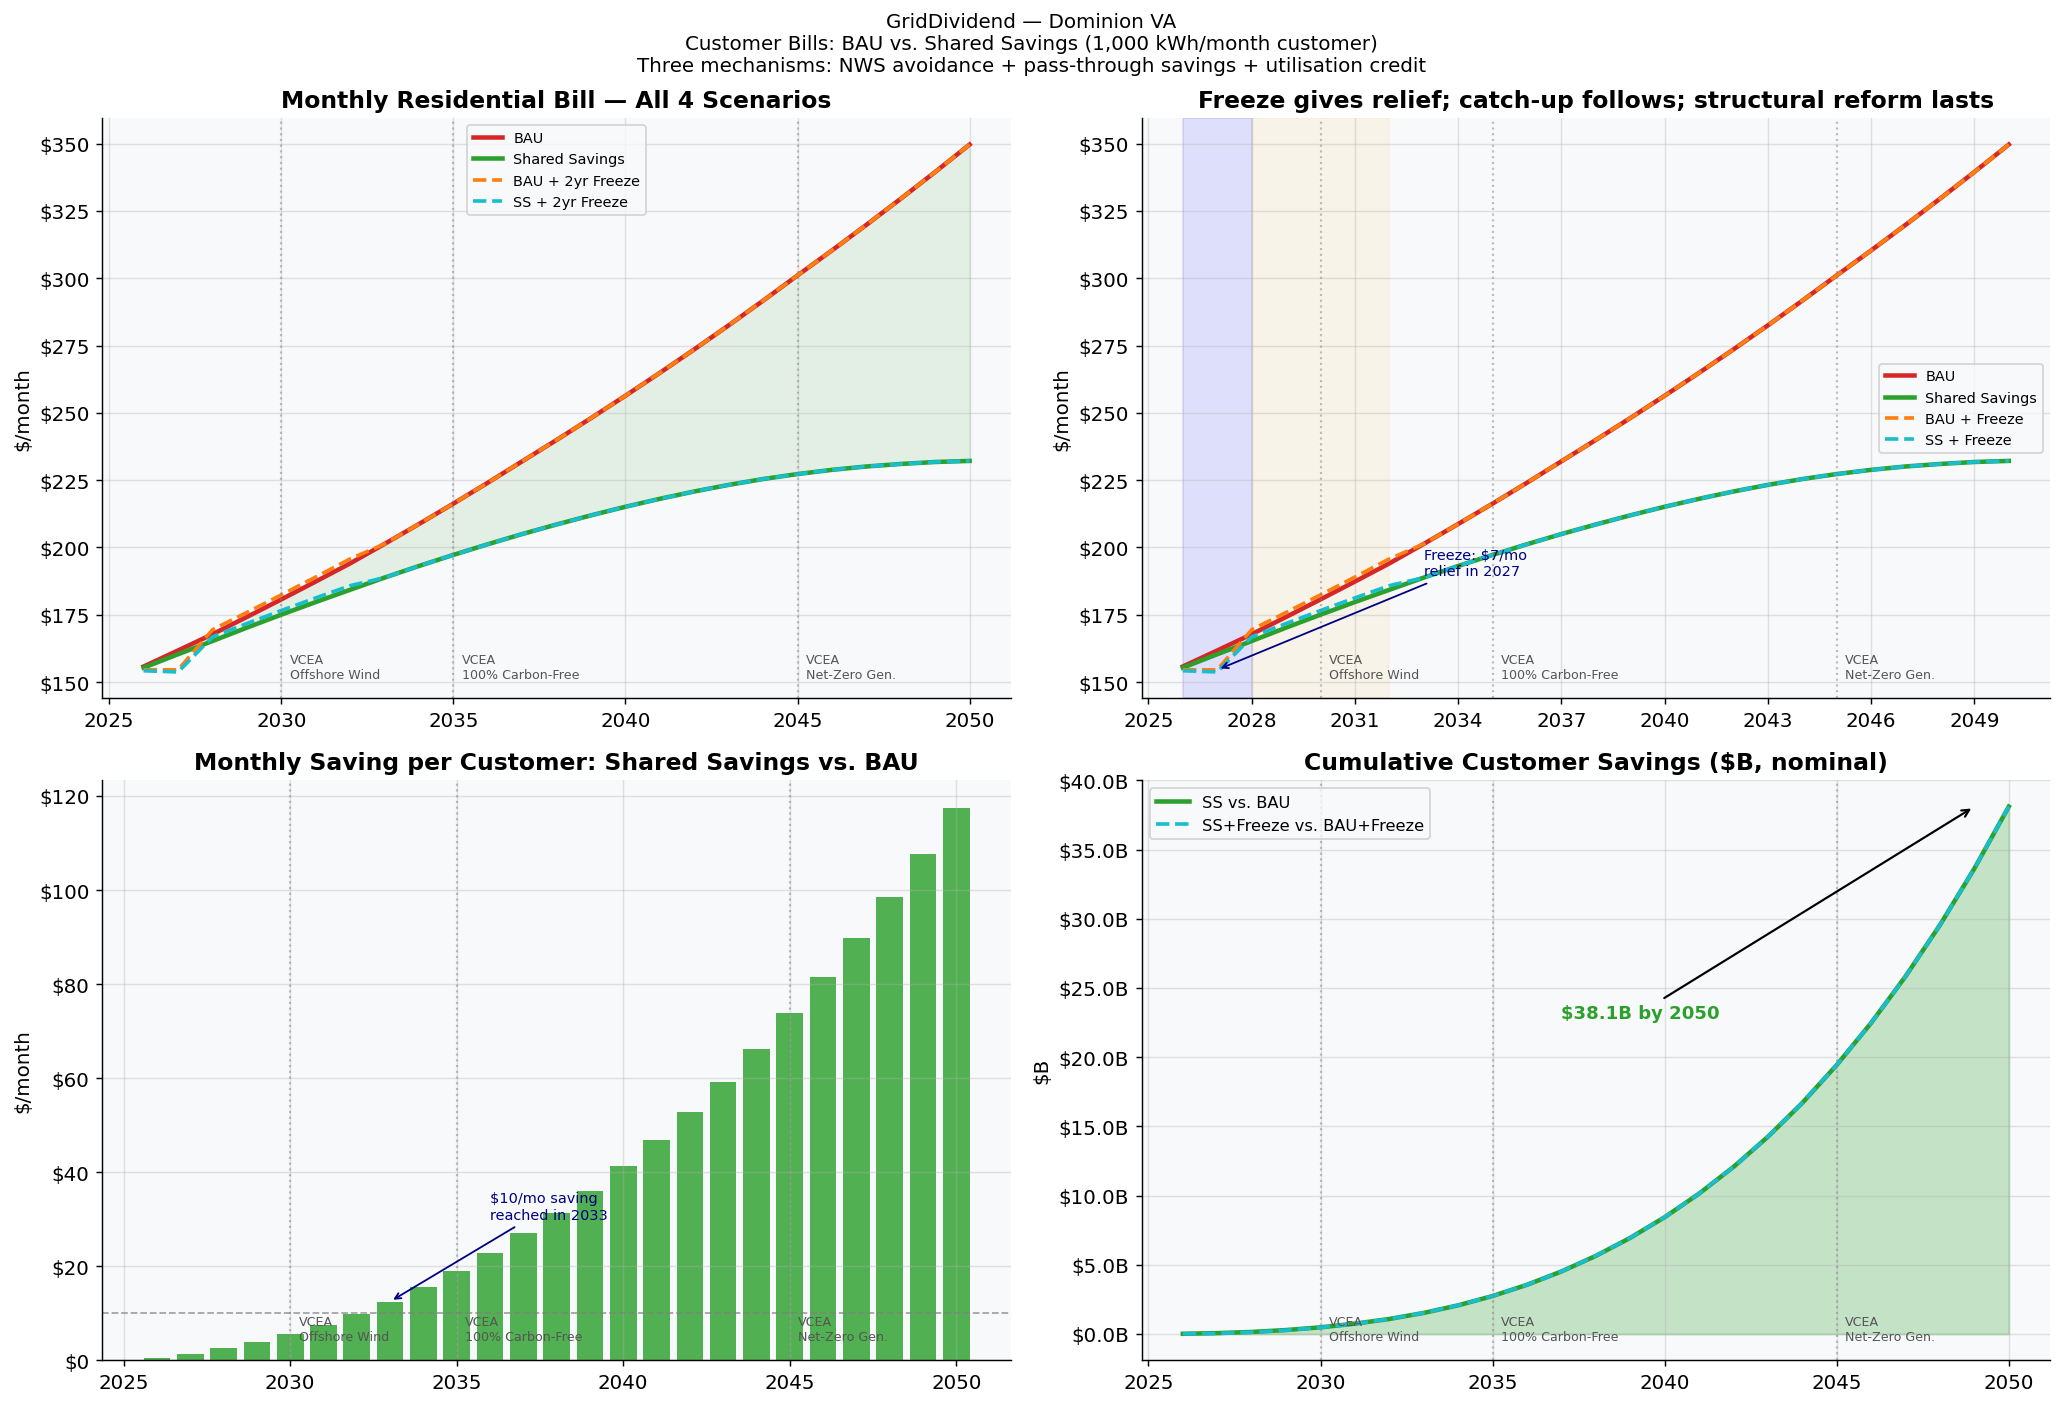


Dominion VA — Bill Results Table (1,000 kWh/month)
  Year    BAU$/mo    SS$/mo    BAU+Frz    SS+Frz   Saving/yr       %    Cum$B
  ----------------------------------------------------------------------
  2026     155.8    155.4     154.6    154.2          5    0.3%      0.0
  2027     161.8    160.4     154.6    153.8         17    0.9%      0.1
  2028     167.8    165.3     169.5    166.8         30    1.5%      0.1
  2030     180.7    175.1     182.4    176.6         68    3.1%      0.5
  2032     194.1    184.3     195.8    185.8        118    5.1%      1.1
  2035     216.3    197.2     216.3    197.2        228    8.8%      2.7
  2040     256.4    215.1     256.4    215.1        495   16.1%      8.4
  2045     301.0    227.3     301.0    227.3        885   24.5%     19.4
  2050     349.6    232.2     349.6    232.2      1,410   33.6%     38.1



In [9]:
for k in utilities_to_run:
    bau   = results[k]['bau'];   sh    = results[k]['shared']
    bau_f = results[k]['bau_freeze']; sh_f = results[k]['shared_freeze']
    name  = UTILITIES[k]['short_name']
    p     = utility_data[k]

    ann_sav_mo = bau['avg_monthly_bill'].values - sh['avg_monthly_bill'].values
    ann_sav_yr = bau['avg_annual_bill'].values  - sh['avg_annual_bill'].values
    cum_sav    = np.cumsum(ann_sav_yr * sh['customers'].values / 1e6) / 1000

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle(
        f'GridDividend — {name}\n'
        f'Customer Bills: BAU vs. Shared Savings ({p["residential_kwh_month"]:,.0f} kWh/month customer)\n'
        f'Three mechanisms: NWS avoidance + pass-through savings + utilisation credit',
        fontsize=11)

    # All 4 scenarios — full timeline
    ax = axes[0, 0]
    ax.plot(YEARS, bau['avg_monthly_bill'],   color=C['bau'],          lw=2.5, label='BAU')
    ax.plot(YEARS, sh['avg_monthly_bill'],    color=C['shared'],        lw=2.5, label='Shared Savings')
    ax.plot(YEARS, bau_f['avg_monthly_bill'], color=C['freeze_bau'],   lw=2, ls='--', label='BAU + 2yr Freeze')
    ax.plot(YEARS, sh_f['avg_monthly_bill'],  color=C['freeze_shared'], lw=2, ls='--', label='SS + 2yr Freeze')
    ax.fill_between(YEARS, sh['avg_monthly_bill'], bau['avg_monthly_bill'], alpha=0.10, color=C['shared'])
    vlines(ax)
    ax.set_title('Monthly Residential Bill — All 4 Scenarios')
    ax.set_ylabel('$/month')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=8)

    # Near-term zoom: freeze effect
    ax = axes[0, 1]
    zoom = list(YEARS)
    filt = lambda df, c: list(df[c])
    ax.plot(zoom, filt(bau,   'avg_monthly_bill'), color=C['bau'],          lw=2.5, label='BAU')
    ax.plot(zoom, filt(sh,    'avg_monthly_bill'), color=C['shared'],        lw=2.5, label='Shared Savings')
    ax.plot(zoom, filt(bau_f, 'avg_monthly_bill'), color=C['freeze_bau'],   lw=2, ls='--', label='BAU + Freeze')
    ax.plot(zoom, filt(sh_f,  'avg_monthly_bill'), color=C['freeze_shared'], lw=2, ls='--', label='SS + Freeze')
    ax.axvspan(2026, 2028, alpha=0.10, color='blue')
    ax.axvspan(2028, 2032, alpha=0.07, color='orange')
    b27  = bau_f[bau_f['year'] == 2027].iloc[0]
    b27n = bau[bau['year']   == 2027].iloc[0]
    relief = b27n['avg_monthly_bill'] - b27['avg_monthly_bill']
    ax.annotate(
        f'Freeze: ${relief:.0f}/mo\nrelief in 2027',
        xy=(2027, b27['avg_monthly_bill']),
        xytext=(2033, b27['avg_monthly_bill'] + 35),
        arrowprops=dict(arrowstyle='->', color='navy', lw=1), fontsize=8, color='navy')
    vlines(ax)
    ax.set_title('Freeze gives relief; catch-up follows; structural reform lasts')
    ax.set_ylabel('$/month')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

    # Monthly saving bar chart
    ax = axes[1, 0]
    ax.bar(YEARS, ann_sav_mo,
           color=[C['shared'] if s > 0 else C['bau'] for s in ann_sav_mo],
           alpha=0.82, width=0.8)
    ax.axhline(10, color='gray', ls='--', lw=1, alpha=0.7)
    over10 = np.where(ann_sav_mo > 10)[0]
    if len(over10):
        first_i = over10[0]
        ax.annotate(f'$10/mo saving\nreached in {YEARS[first_i]}',
                    xy=(YEARS[first_i], ann_sav_mo[first_i]),
                    xytext=(YEARS[first_i] + 3, ann_sav_mo[first_i] + ann_sav_mo.max() * 0.15),
                    arrowprops=dict(arrowstyle='->', color='navy', lw=1),
                    fontsize=8, color='navy')
    vlines(ax)
    ax.set_title('Monthly Saving per Customer: Shared Savings vs. BAU')
    ax.set_ylabel('$/month')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Cumulative savings
    ax = axes[1, 1]
    ax.fill_between(YEARS, 0, cum_sav, alpha=0.25, color=C['shared'])
    ax.plot(YEARS, cum_sav, color=C['shared'], lw=2.5, label='SS vs. BAU')
    ann_sav_f = bau_f['avg_annual_bill'].values - sh_f['avg_annual_bill'].values
    cum_sav_f = np.cumsum(ann_sav_f * sh_f['customers'].values / 1e6) / 1000
    ax.plot(YEARS, cum_sav_f, color=C['freeze_shared'], lw=2, ls='--', label='SS+Freeze vs. BAU+Freeze')
    vlines(ax)
    ax.set_title('Cumulative Customer Savings ($B, nominal)')
    ax.set_ylabel('$B')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}B'))
    final = cum_sav[-1]
    ax.annotate(f'${final:.1f}B by 2050', xy=(2049, final), xytext=(2037, final * 0.6),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
        fontsize=10, fontweight='bold', color=C['shared'])
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'charts/chart1_bills_{k.lower()}.png', bbox_inches='tight', dpi=130)
    plt.show()

    # Results table
    print(f"\n{name} — Bill Results Table ({p['residential_kwh_month']:,.0f} kWh/month)")
    print(f"  {'Year':>4}  {'BAU$/mo':>9}  {'SS$/mo':>8}  {'BAU+Frz':>9}  {'SS+Frz':>8}"
          f"  {'Saving/yr':>10}  {'%':>6}  {'Cum$B':>7}")
    print("  " + "-" * 70)
    for yr in [2026, 2027, 2028, 2030, 2032, 2035, 2040, 2045, 2050]:
        br  = bau[bau['year']   == yr].iloc[0]
        sr  = sh[sh['year']    == yr].iloc[0]
        brf = bau_f[bau_f['year'] == yr].iloc[0]
        srf = sh_f[sh_f['year']  == yr].iloc[0]
        sv  = br['avg_annual_bill'] - sr['avg_annual_bill']
        idx = YEARS.index(yr)
        cumv = np.sum(
            (bau['avg_annual_bill'].values[:idx+1] - sh['avg_annual_bill'].values[:idx+1])
            * sh['customers'].values[:idx+1]) / 1e9
        print(f"  {yr:4d}   {br['avg_monthly_bill']:>7,.1f}   {sr['avg_monthly_bill']:>6,.1f}"
              f"   {brf['avg_monthly_bill']:>7,.1f}   {srf['avg_monthly_bill']:>6,.1f}"
              f"   {sv:>8,.0f}   {sv/br['avg_annual_bill']:>5.1%}   {cumv:>6.1f}")
    print()

## Section 6: Infrastructure Spending — CAPEX & OPEX

Shows utilities still invest heavily under shared savings — NWS defers a growing but bounded share of growth-driven upgrades. Both CAPEX spent and CAPEX avoided increase year-on-year.

Both utilities are shown. **Con Edison**: cumulative grid spend falls from ~$155B BAU to ~$120B SS ($35B, 22% saving). **RG&E**: cumulative grid spend falls from ~$9.0B BAU to ~$6.6B SS ($2.5B, 27% saving). RG&E's proportionally larger saving reflects its programme being more heavily weighted toward growth-driven overhead reinforcements well-suited to NWS deferral.

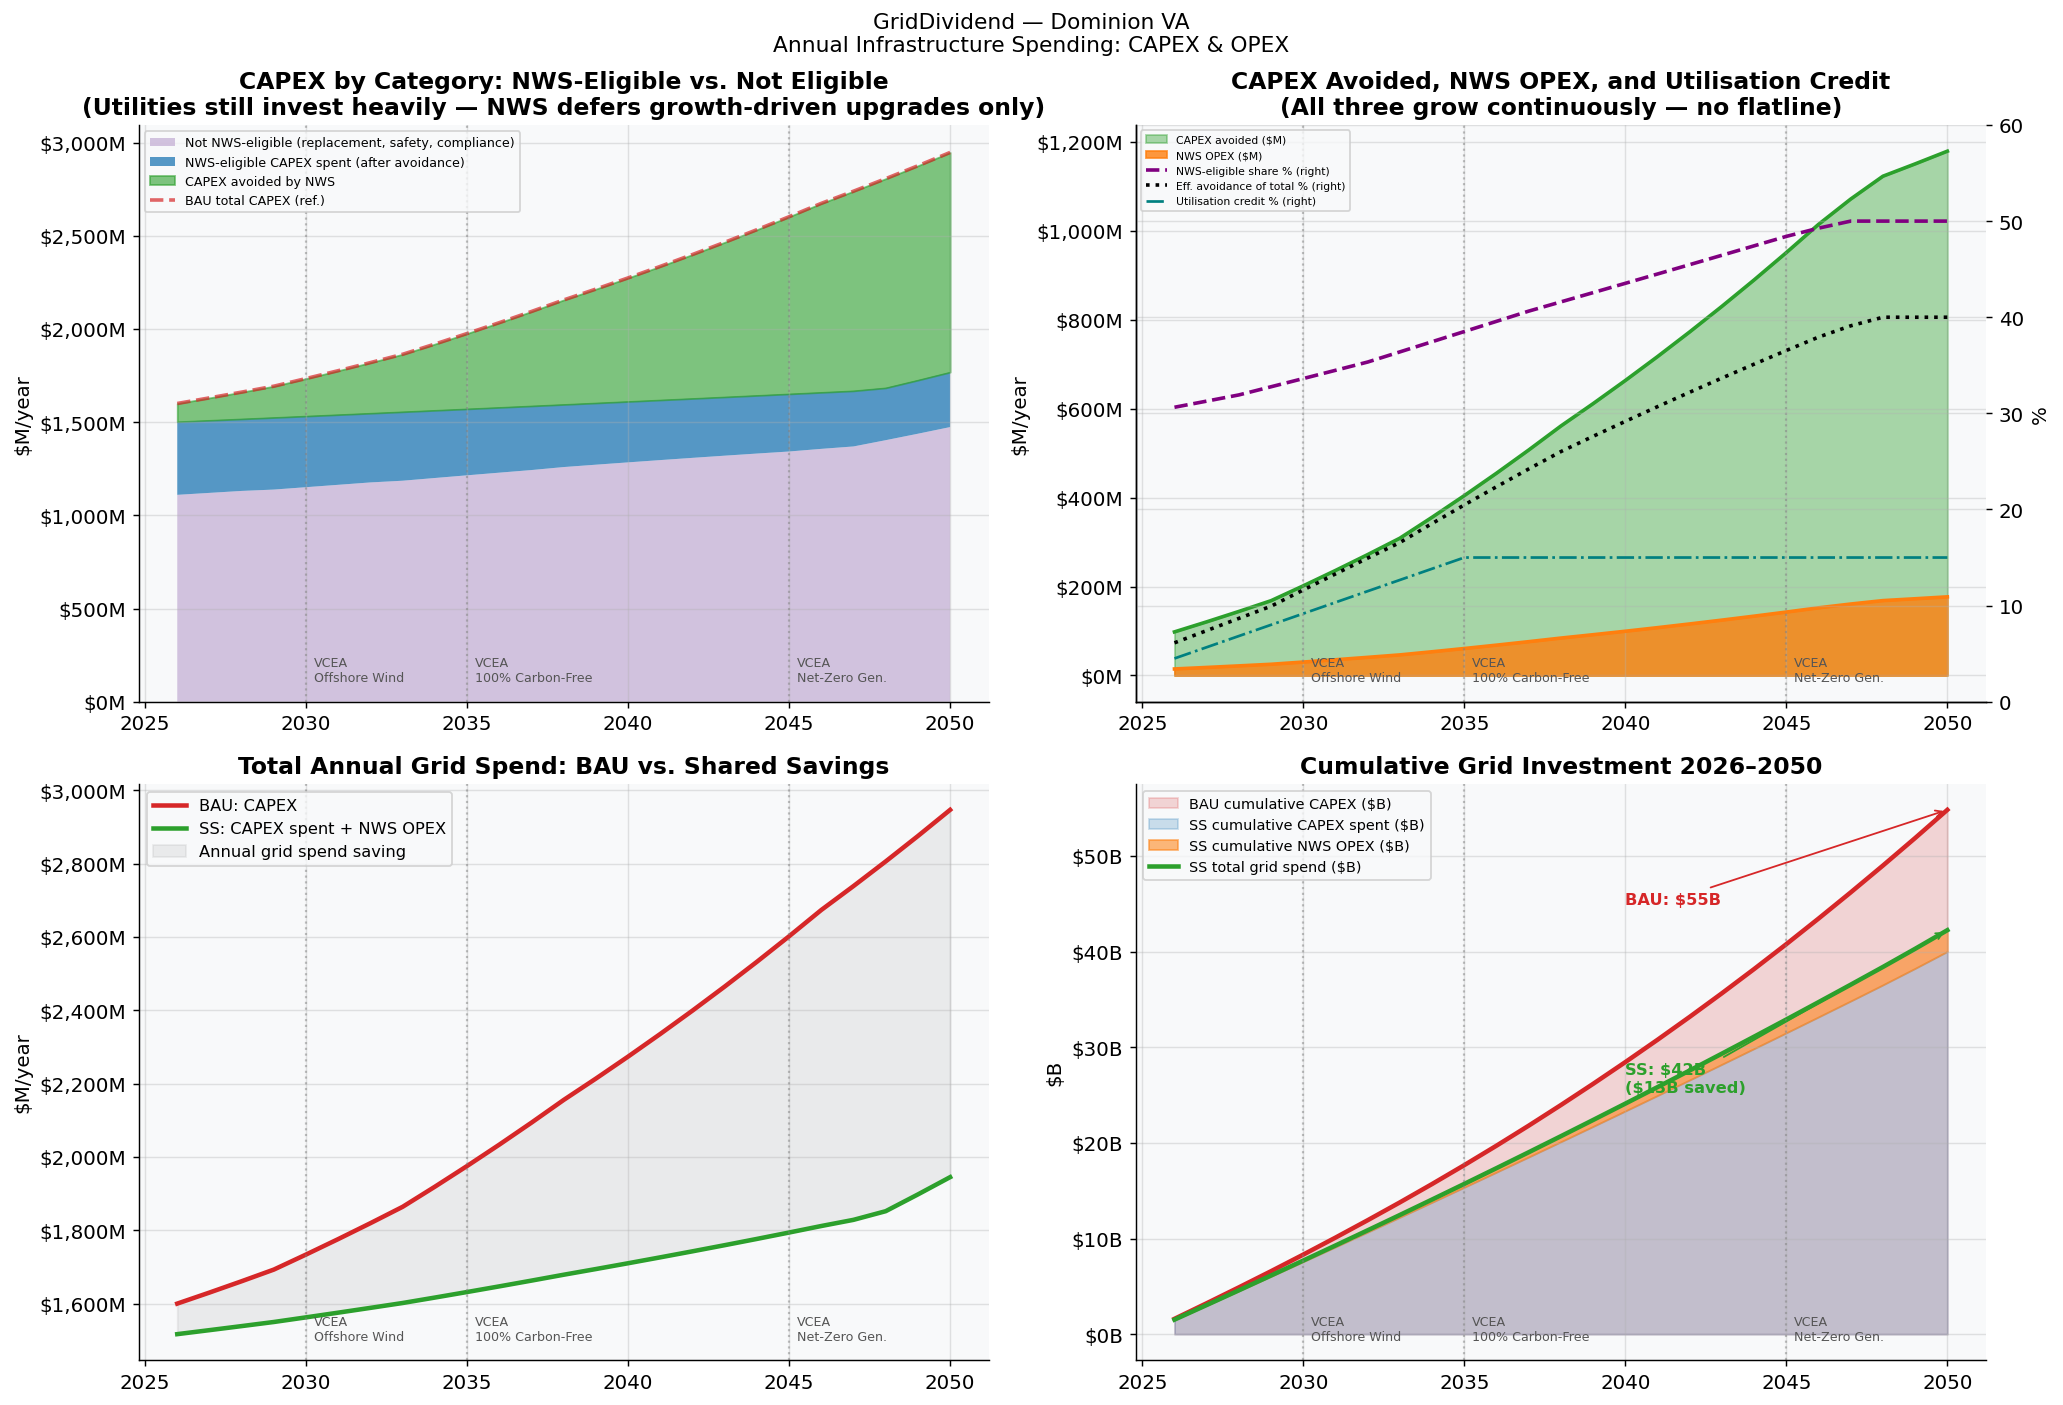


Dominion VA — CAPEX & NWS OPEX Table
  Year    BAU CAPEX    Elig%    Avoided    SS Spent    NWS OPEX   Eff.Avoid%
  ------------------------------------------------------------------------
  2026       1,600    30.6%       98      1,502         15         6.1%
  2028       1,661    31.9%      144      1,517         22         8.7%
  2030       1,734    33.6%      202      1,532         30        11.6%
  2035       1,975    38.5%      404      1,571         61        20.5%
  2040       2,274    43.5%      663      1,611         99        29.2%
  2045       2,602    48.4%      951      1,651        143        36.5%
  2050       2,947    50.0%    1,179      1,768        177        40.0%



In [10]:
for k in utilities_to_run:
    bau  = results[k]['bau']; sh = results[k]['shared']
    name = UTILITIES[k]['short_name']
    bau_cum    = np.cumsum(bau['capex_spent_m'].values)
    ss_cum     = np.cumsum(sh['capex_spent_m'].values)
    ss_nws_cum = np.cumsum(sh['nws_opex_m'].values)

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle(f'GridDividend — {name}\nAnnual Infrastructure Spending: CAPEX & OPEX', fontsize=12)

    ax = axes[0, 0]
    ax.stackplot(YEARS, sh['capex_ineligible_m'],
                 sh['capex_spent_m'] - sh['capex_ineligible_m'],
                 labels=['Not NWS-eligible (replacement, safety, compliance)',
                         'NWS-eligible CAPEX spent (after avoidance)'],
                 colors=[C['ineligible'], C['capex_spent']], alpha=0.75)
    ax.fill_between(YEARS, sh['capex_spent_m'], sh['capex_total_programme_m'],
                    alpha=0.60, color=C['capex_avoided'], label='CAPEX avoided by NWS')
    ax.plot(YEARS, bau['capex_spent_m'], color=C['bau'], lw=2, ls='--', alpha=0.7,
            label='BAU total CAPEX (ref.)')
    vlines(ax)
    ax.set_title('CAPEX by Category: NWS-Eligible vs. Not Eligible\n'
                 '(Utilities still invest heavily — NWS defers growth-driven upgrades only)')
    ax.set_ylabel('$M/year')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(fontsize=7, loc='upper left')

    ax = axes[0, 1]
    ax2 = ax.twinx()
    ax.fill_between(YEARS, 0, sh['capex_avoided_m'], alpha=0.40, color=C['capex_avoided'],
                    label='CAPEX avoided ($M)')
    ax.fill_between(YEARS, 0, sh['nws_opex_m'], alpha=0.80, color=C['opex_nws'],
                    label='NWS OPEX ($M)')
    ax.plot(YEARS, sh['capex_avoided_m'], color=C['capex_avoided'], lw=2)
    ax.plot(YEARS, sh['nws_opex_m'],      color=C['opex_nws'],      lw=2)
    ax2.plot(YEARS, sh['nws_eligible_share_pct'],       color='purple', lw=2, ls='--',
             label='NWS-eligible share % (right)')
    ax2.plot(YEARS, sh['capex_avoidance_pct_of_total'], color='black',  lw=2, ls=':',
             label='Eff. avoidance of total % (right)')
    ax2.plot(YEARS, sh['utilisation_credit_pct'].values,
             color='teal', lw=1.5, ls='-.', label='Utilisation credit % (right)')
    ax2.set_ylim(0, 60); ax2.set_ylabel('%')
    vlines(ax)
    ax.set_title('CAPEX Avoided, NWS OPEX, and Utilisation Credit\n'
                 '(All three grow continuously — no flatline)')
    ax.set_ylabel('$M/year')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, lb1 + lb2, fontsize=6, loc='upper left')

    ax = axes[1, 0]
    ax.plot(YEARS, bau['capex_spent_m'],    color=C['bau'],    lw=2.5, label='BAU: CAPEX')
    ax.plot(YEARS, sh['total_grid_spend_m'], color=C['shared'], lw=2.5,
            label='SS: CAPEX spent + NWS OPEX')
    ax.fill_between(YEARS, sh['total_grid_spend_m'], bau['capex_spent_m'],
                    alpha=0.13, color=C['neutral'], label='Annual grid spend saving')
    vlines(ax)
    ax.set_title('Total Annual Grid Spend: BAU vs. Shared Savings')
    ax.set_ylabel('$M/year')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(fontsize=9)

    ax = axes[1, 1]
    ax.fill_between(YEARS, 0, bau_cum / 1000, alpha=0.18, color=C['bau'],
                    label='BAU cumulative CAPEX ($B)')
    ax.fill_between(YEARS, 0, ss_cum / 1000, alpha=0.22, color=C['capex_spent'],
                    label='SS cumulative CAPEX spent ($B)')
    ax.fill_between(YEARS, ss_cum / 1000, (ss_cum + ss_nws_cum) / 1000, alpha=0.55,
                    color=C['opex_nws'], label='SS cumulative NWS OPEX ($B)')
    ax.plot(YEARS, bau_cum / 1000, color=C['bau'], lw=2.5)
    ax.plot(YEARS, (ss_cum + ss_nws_cum) / 1000, color=C['shared'], lw=2.5,
            label='SS total grid spend ($B)')
    b2050 = bau_cum[-1] / 1000; s2050 = (ss_cum[-1] + ss_nws_cum[-1]) / 1000
    ax.annotate(f'BAU: ${b2050:.0f}B', xy=(2050, b2050), xytext=(2040, b2050 * 0.82),
        arrowprops=dict(arrowstyle='->', color=C['bau'], lw=1),
        fontsize=9, color=C['bau'], fontweight='bold')
    ax.annotate(f'SS: ${s2050:.0f}B\n(${b2050-s2050:.0f}B saved)',
        xy=(2050, s2050), xytext=(2040, s2050 * 0.60),
        arrowprops=dict(arrowstyle='->', color=C['shared'], lw=1),
        fontsize=9, color=C['shared'], fontweight='bold')
    vlines(ax)
    ax.set_title('Cumulative Grid Investment 2026–2050')
    ax.set_ylabel('$B')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'charts/chart2_capex_opex_{k.lower()}.png', bbox_inches='tight', dpi=130)
    plt.show()

    print(f"\n{name} — CAPEX & NWS OPEX Table")
    print(f"  {'Year':>4}  {'BAU CAPEX':>11}  {'Elig%':>7}  {'Avoided':>9}  "
          f"{'SS Spent':>10}  {'NWS OPEX':>10}  {'Eff.Avoid%':>11}")
    print("  " + "-" * 72)
    for yr in [2026, 2028, 2030, 2035, 2040, 2045, 2050]:
        br = bau[bau['year'] == yr].iloc[0]; sr = sh[sh['year'] == yr].iloc[0]
        print(f"  {yr:4d}   {br['capex_spent_m']:>9,.0f}  "
              f"{sr['nws_eligible_share_pct']:>6.1f}%  "
              f"{sr['capex_avoided_m']:>7,.0f}   "
              f"{sr['capex_spent_m']:>8,.0f}   "
              f"{sr['nws_opex_m']:>8,.0f}   "
              f"{sr['capex_avoidance_pct_of_total']:>9.1f}%")
    print()

## Section 7: Utility Financial Results

Under shared savings, utility revenue exceeds BAU in the **early years** of the programme — the period when the utility most needs the commercial incentive to build NWS capabilities. As the avoided rate base accumulates, the compounding effect of foregone traditional earnings creates a crossover around the mid-2030s. This underscores why regulatory design matters: the shared savings percentage, performance corridor, and ROE framework need to be calibrated to keep the utility commercially motivated throughout the programme, not just in its early years.

**The early-year arithmetic:** the utility earns ~25¢ of shared savings income per $1 of deferred CAPEX but loses only ~7¢ in traditional earnings — a net benefit of ~18¢ per deferred dollar. This is what makes the reform commercially viable in its critical early phase.

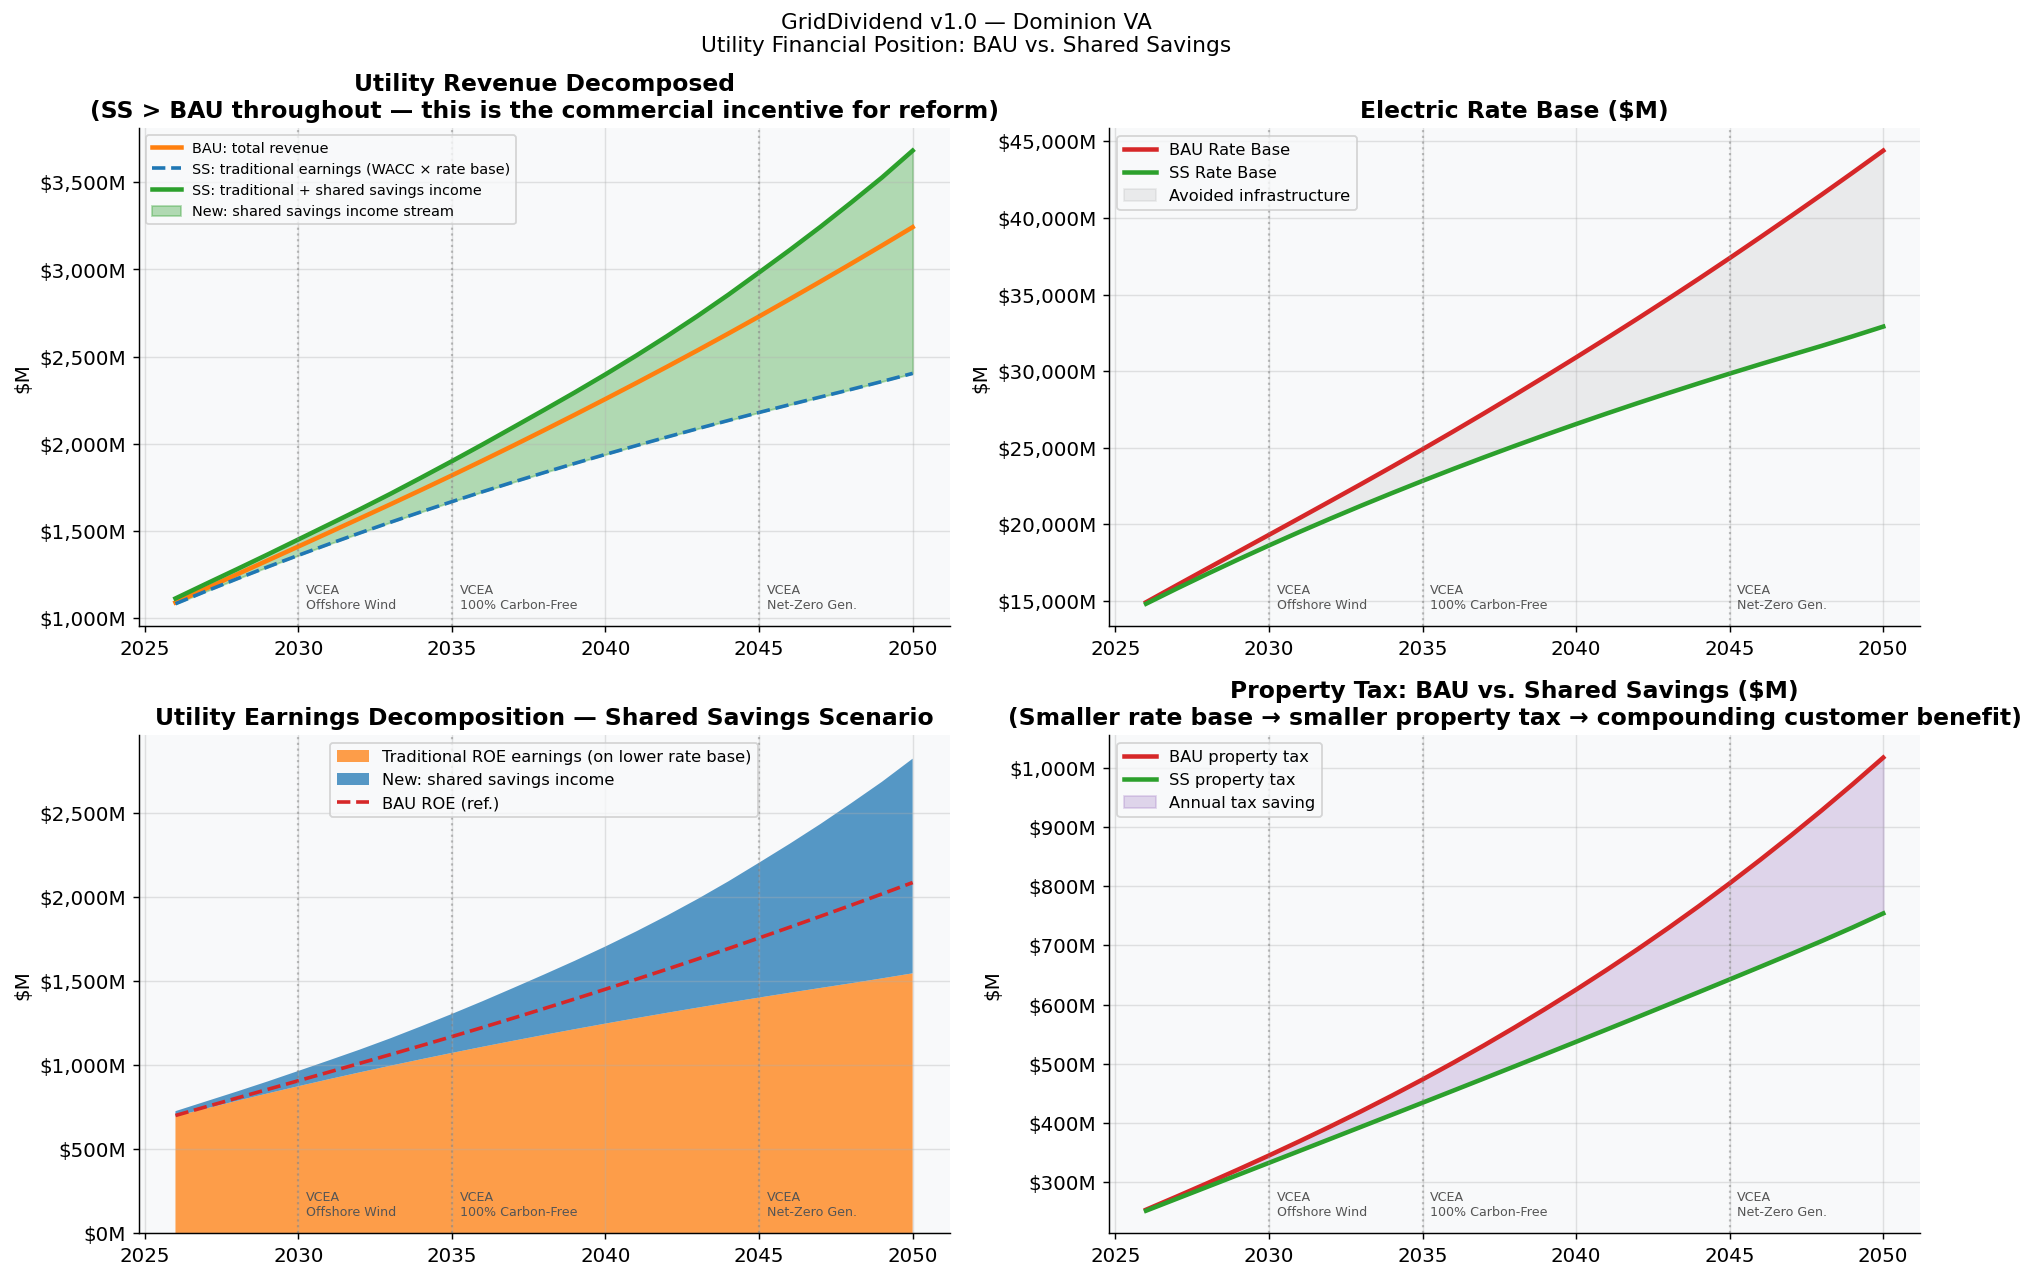

In [11]:
for k in utilities_to_run:
    bau  = results[k]['bau']; sh = results[k]['shared']
    name = UTILITIES[k]['short_name']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'GridDividend v1.0 — {name}\nUtility Financial Position: BAU vs. Shared Savings',
                 fontsize=12)

    ax = axes[0, 0]
    ax.plot(YEARS, bau['total_utility_revenue_m'], color=C['util_bau'], lw=2.5, label='BAU: total revenue')
    ax.plot(YEARS, sh['traditional_earnings_m'], color=C['util_shared'], lw=2, ls='--',
            label='SS: traditional earnings (WACC × rate base)')
    ax.plot(YEARS, sh['total_utility_revenue_m'], color=C['shared'], lw=2.5,
            label='SS: traditional + shared savings income')
    ax.fill_between(YEARS, sh['traditional_earnings_m'], sh['total_utility_revenue_m'],
                    alpha=0.35, color=C['shared'], label='New: shared savings income stream')
    vlines(ax)
    ax.set_title('Utility Revenue Decomposed\n'
                 '(SS > BAU throughout — this is the commercial incentive for reform)')
    ax.set_ylabel('$M')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(fontsize=8, loc='upper left')

    ax = axes[0, 1]
    ax.plot(YEARS, bau['rate_base_m'], color=C['bau'],    lw=2.5, label='BAU Rate Base')
    ax.plot(YEARS, sh['rate_base_m'],  color=C['shared'], lw=2.5, label='SS Rate Base')
    ax.fill_between(YEARS, sh['rate_base_m'], bau['rate_base_m'],
                    alpha=0.13, color=C['neutral'], label='Avoided infrastructure')
    vlines(ax)
    ax.set_title('Electric Rate Base ($M)')
    ax.set_ylabel('$M')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(fontsize=9)

    ax = axes[1, 0]
    ax.stackplot(YEARS, sh['roe_earnings_m'], sh['utility_shared_revenue_m'],
        labels=['Traditional ROE earnings (on lower rate base)', 'New: shared savings income'],
        colors=[C['util_bau'], C['util_shared']], alpha=0.75)
    ax.plot(YEARS, bau['roe_earnings_m'], color=C['bau'], lw=2, ls='--', label='BAU ROE (ref.)')
    vlines(ax)
    ax.set_title('Utility Earnings Decomposition — Shared Savings Scenario')
    ax.set_ylabel('$M')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(fontsize=9)

    ax = axes[1, 1]
    ax.plot(YEARS, bau['property_tax_m'], color=C['bau'],    lw=2.5, label='BAU property tax')
    ax.plot(YEARS, sh['property_tax_m'],  color=C['shared'], lw=2.5, label='SS property tax')
    ax.fill_between(YEARS, sh['property_tax_m'], bau['property_tax_m'],
                    alpha=0.25, color=C['tax'], label='Annual tax saving')
    vlines(ax)
    ax.set_title('Property Tax: BAU vs. Shared Savings ($M)\n'
                 '(Smaller rate base → smaller property tax → compounding customer benefit)')
    ax.set_ylabel('$M')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'charts/chart3_utility_{k.lower()}.png', bbox_inches='tight', dpi=130)
    plt.show()

## Section 8: Sensitivity Analysis

Tests how results change across parameter ranges. Dot = default value.

**Note on parameter correlation:** The analysis below varies one parameter at a time, holding all others constant. In practice many parameters are correlated — high electrification growth tends to increase NWS opportunity but also increases operational complexity and may reduce effective avoidance rates; higher DER penetration is both a driver of flexibility and a source of dispatch uncertainty. A full probabilistic analysis using Monte Carlo methods with correlated parameter draws would produce wider confidence intervals than the ranges shown here. The single-variable sensitivity charts should be read as illustrating which parameters matter most, not as bounding the full range of possible outcomes.

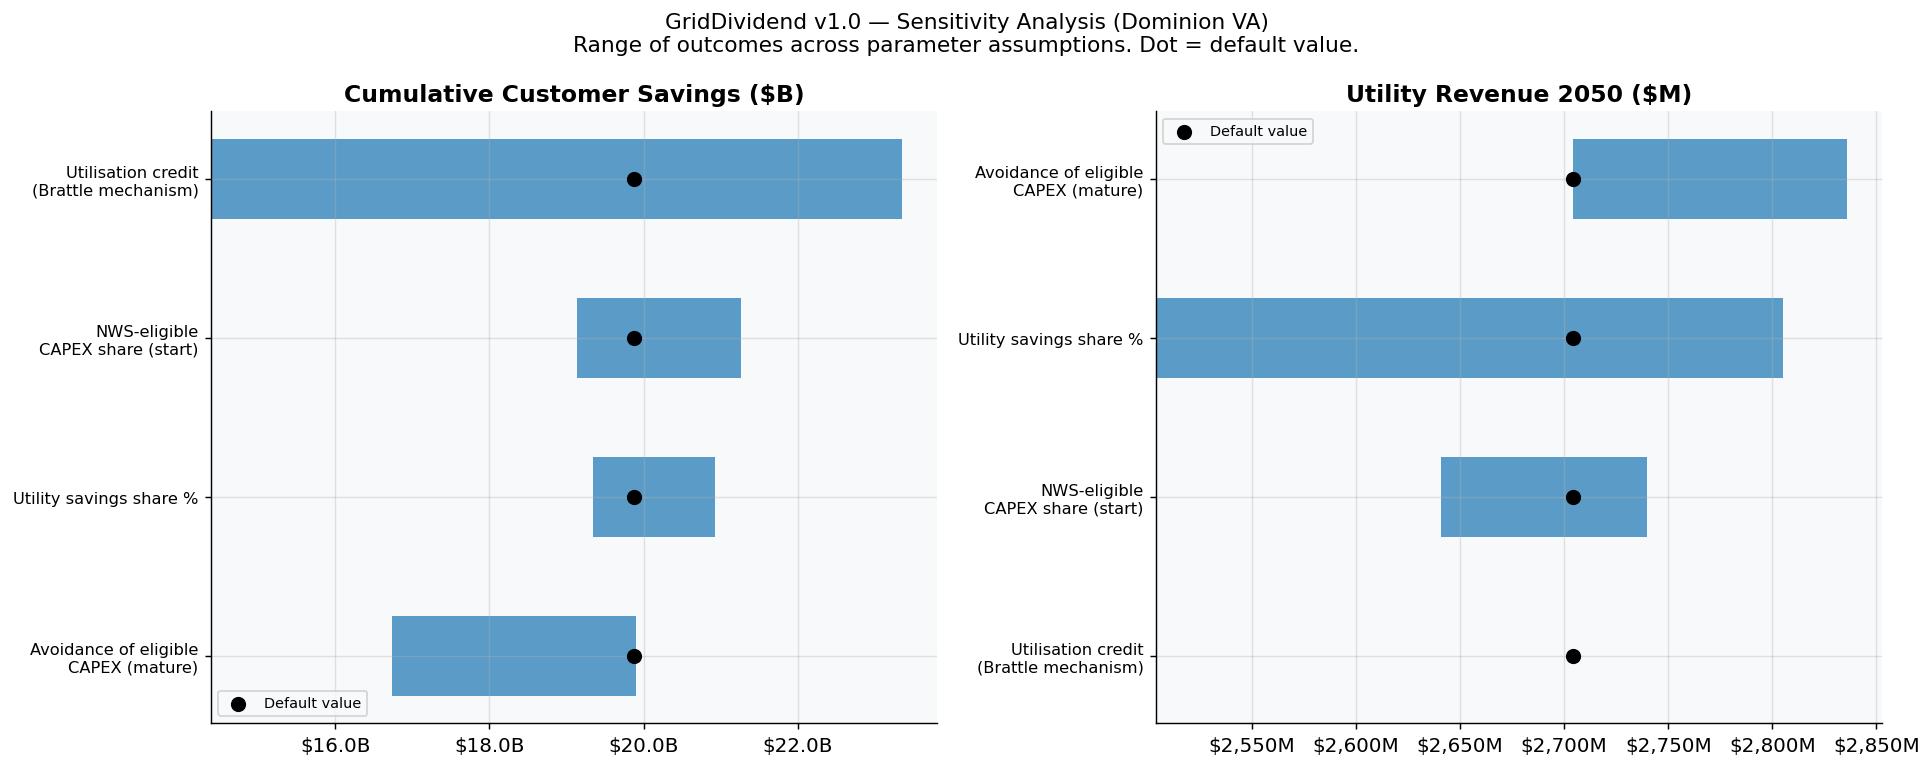

In [12]:
PARAM_DEFAULTS = {
    'NWS_ELIGIBLE_CAPEX_SHARE_START':   0.30,
    'NWS_AVOIDANCE_OF_ELIGIBLE_MATURE': 0.80,
    'UTILITY_SAVINGS_SHARE':            0.30,
    'FLEX_LOAD_UTILISATION_SHARE_SS':   0.15,
}
SENSITIVITY_RUNS = {
    'NWS_ELIGIBLE_CAPEX_SHARE_START':   [0.20, 0.25, 0.30, 0.40, 0.50],
    'NWS_AVOIDANCE_OF_ELIGIBLE_MATURE': [0.50, 0.65, 0.80, 0.90],
    'UTILITY_SAVINGS_SHARE':            [0.10, 0.20, 0.30, 0.40],
    'FLEX_LOAD_UTILISATION_SHARE_SS':   [0.00, 0.08, 0.15, 0.25],
}
PARAM_LABELS = {
    'NWS_ELIGIBLE_CAPEX_SHARE_START':   'NWS-eligible\nCAPEX share (start)',
    'NWS_AVOIDANCE_OF_ELIGIBLE_MATURE': 'Avoidance of eligible\nCAPEX (mature)',
    'UTILITY_SAVINGS_SHARE':            'Utility savings share %',
    'FLEX_LOAD_UTILISATION_SHARE_SS':   'Utilisation credit\n(Brattle mechanism)',
}

k = utilities_to_run[0]
p = utility_data[k]; bau_df = results[k]['bau']
all_sens = []
for pname, pvals in SENSITIVITY_RUNS.items():
    recs = []
    for val in pvals:
        cfg = {**MODEL_CONFIG, pname: val}
        s = project(p, 'shared', config=cfg)
        cum_b = np.sum((bau_df['avg_annual_bill'].values - s['avg_annual_bill'].values)
                       * s['customers'].values) / 1e9
        ur = s[s['year'] == 2050]['total_utility_revenue_m'].values[0]
        recs.append({'parameter': pname, 'value': val, 'cum_b': round(cum_b, 2), 'ur': round(ur, 0)})
    all_sens.append(pd.DataFrame(recs))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f'GridDividend v1.0 — Sensitivity Analysis ({UTILITIES[k]["short_name"]})\n'
    f'Range of outcomes across parameter assumptions. Dot = default value.',
    fontsize=12)

for ci, (metric, title) in enumerate([
    ('cum_b', 'Cumulative Customer Savings ($B)'),
    ('ur',    'Utility Revenue 2050 ($M)')]):
    ax = axes[ci]; ranges = []
    for s in all_sens:
        pname   = s['parameter'].iloc[0]
        default = PARAM_DEFAULTS[pname]
        lo = s[metric].min(); hi = s[metric].max()
        dr = s[abs(s['value'] - default) < 1e-9]
        mid = dr[metric].values[0] if len(dr) else (lo + hi) / 2
        ranges.append({'label': PARAM_LABELS[pname], 'lo': lo, 'hi': hi, 'mid': mid})
    rdf = pd.DataFrame(ranges).sort_values('hi', ascending=True)
    yp  = list(range(len(rdf)))
    ax.barh(yp, rdf['hi'] - rdf['lo'], left=rdf['lo'],
            color=C['util_shared'], alpha=0.72, height=0.5)
    ax.scatter(rdf['mid'], yp, color='black', zorder=5, s=55, label='Default')
    ax.set_yticks(yp); ax.set_yticklabels(rdf['label'], fontsize=9)
    ax.set_title(title)
    if metric == 'cum_b':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}B'))
    else:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(['Default value'], fontsize=8)

plt.tight_layout()
plt.savefig('charts/chart4_sensitivity.png', bbox_inches='tight', dpi=130)
plt.show()

## Section 9: Con Edison vs. RG&E — Side-by-Side Comparison

In [13]:
if len(utilities_to_run) < 2:
    print("Set utilities_to_run = ['ConEd', 'RGE'] in Section 1 to see comparison.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle('GridDividend v1.0 — Con Edison vs. RG&E Compared\n'
                 '(Solid = Con Edison · Dashed = RG&E)', fontsize=13)
    panels = [
        ('avg_monthly_bill', 'Monthly Residential Bill ($/month)',  '${:,.0f}'),
        ('avg_annual_bill',  'Annual Residential Bill ($/year)',    '${:,.0f}'),
        ('rate_base_m',      'Electric Rate Base ($M)',             '${:,.0f}M'),
        ('property_tax_m',   'Property Tax on Infrastructure ($M)', '${:,.0f}M'),
        ('capex_spent_m',    'Annual CAPEX Spent ($M)',             '${:,.0f}M'),
        ('cost_per_mwh',     'Cost per MWh Delivered ($)',          '${:,.0f}'),
    ]
    for idx, (col, title, fmt) in enumerate(panels):
        ax = axes[idx // 3][idx % 3]
        for key in utilities_to_run:
            bau = results[key]['bau']; sh = results[key]['shared']
            lbl = UTILITIES[key]['short_name']
            ls  = '--' if key == 'RGE' else '-'
            ax.plot(YEARS, bau[col], color=C['bau'],    lw=2, ls=ls, alpha=0.9, label=f'{lbl} BAU')
            ax.plot(YEARS, sh[col],  color=C['shared'], lw=2, ls=ls, alpha=0.9, label=f'{lbl} SS')
        for yr in MY: ax.axvline(yr, color='gray', ls=':', alpha=0.45, lw=1.1)
        ax.set_title(title, fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _, f=fmt: f.format(x)))
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig('charts/chart5_comparison.png', bbox_inches='tight', dpi=130)
    plt.show()

Set utilities_to_run = ['ConEd', 'RGE'] in Section 1 to see comparison.


## Section 9b: Near-Term vs Long-Term Trade-Off

These scenarios explore the parameter space around near-term vs long-term bill savings. They are not forecasts and do not represent recommendations. BASE is the reference case. ACCELERATED assumes the utility has existing NWS capabilities and the programme reaches maturity faster — this is a legislative design choice about what preconditions the statute should require before the reform takes effect. FREEZE\_PLUS uses a longer rate freeze as the near-term mechanism, accepting deferred cost recovery in exchange for immediate relief. COMBINED layers both approaches. Each has different implications for utility commercial viability, regulatory complexity, and legislative design — the choice between them is a policy question, not a modelling one.

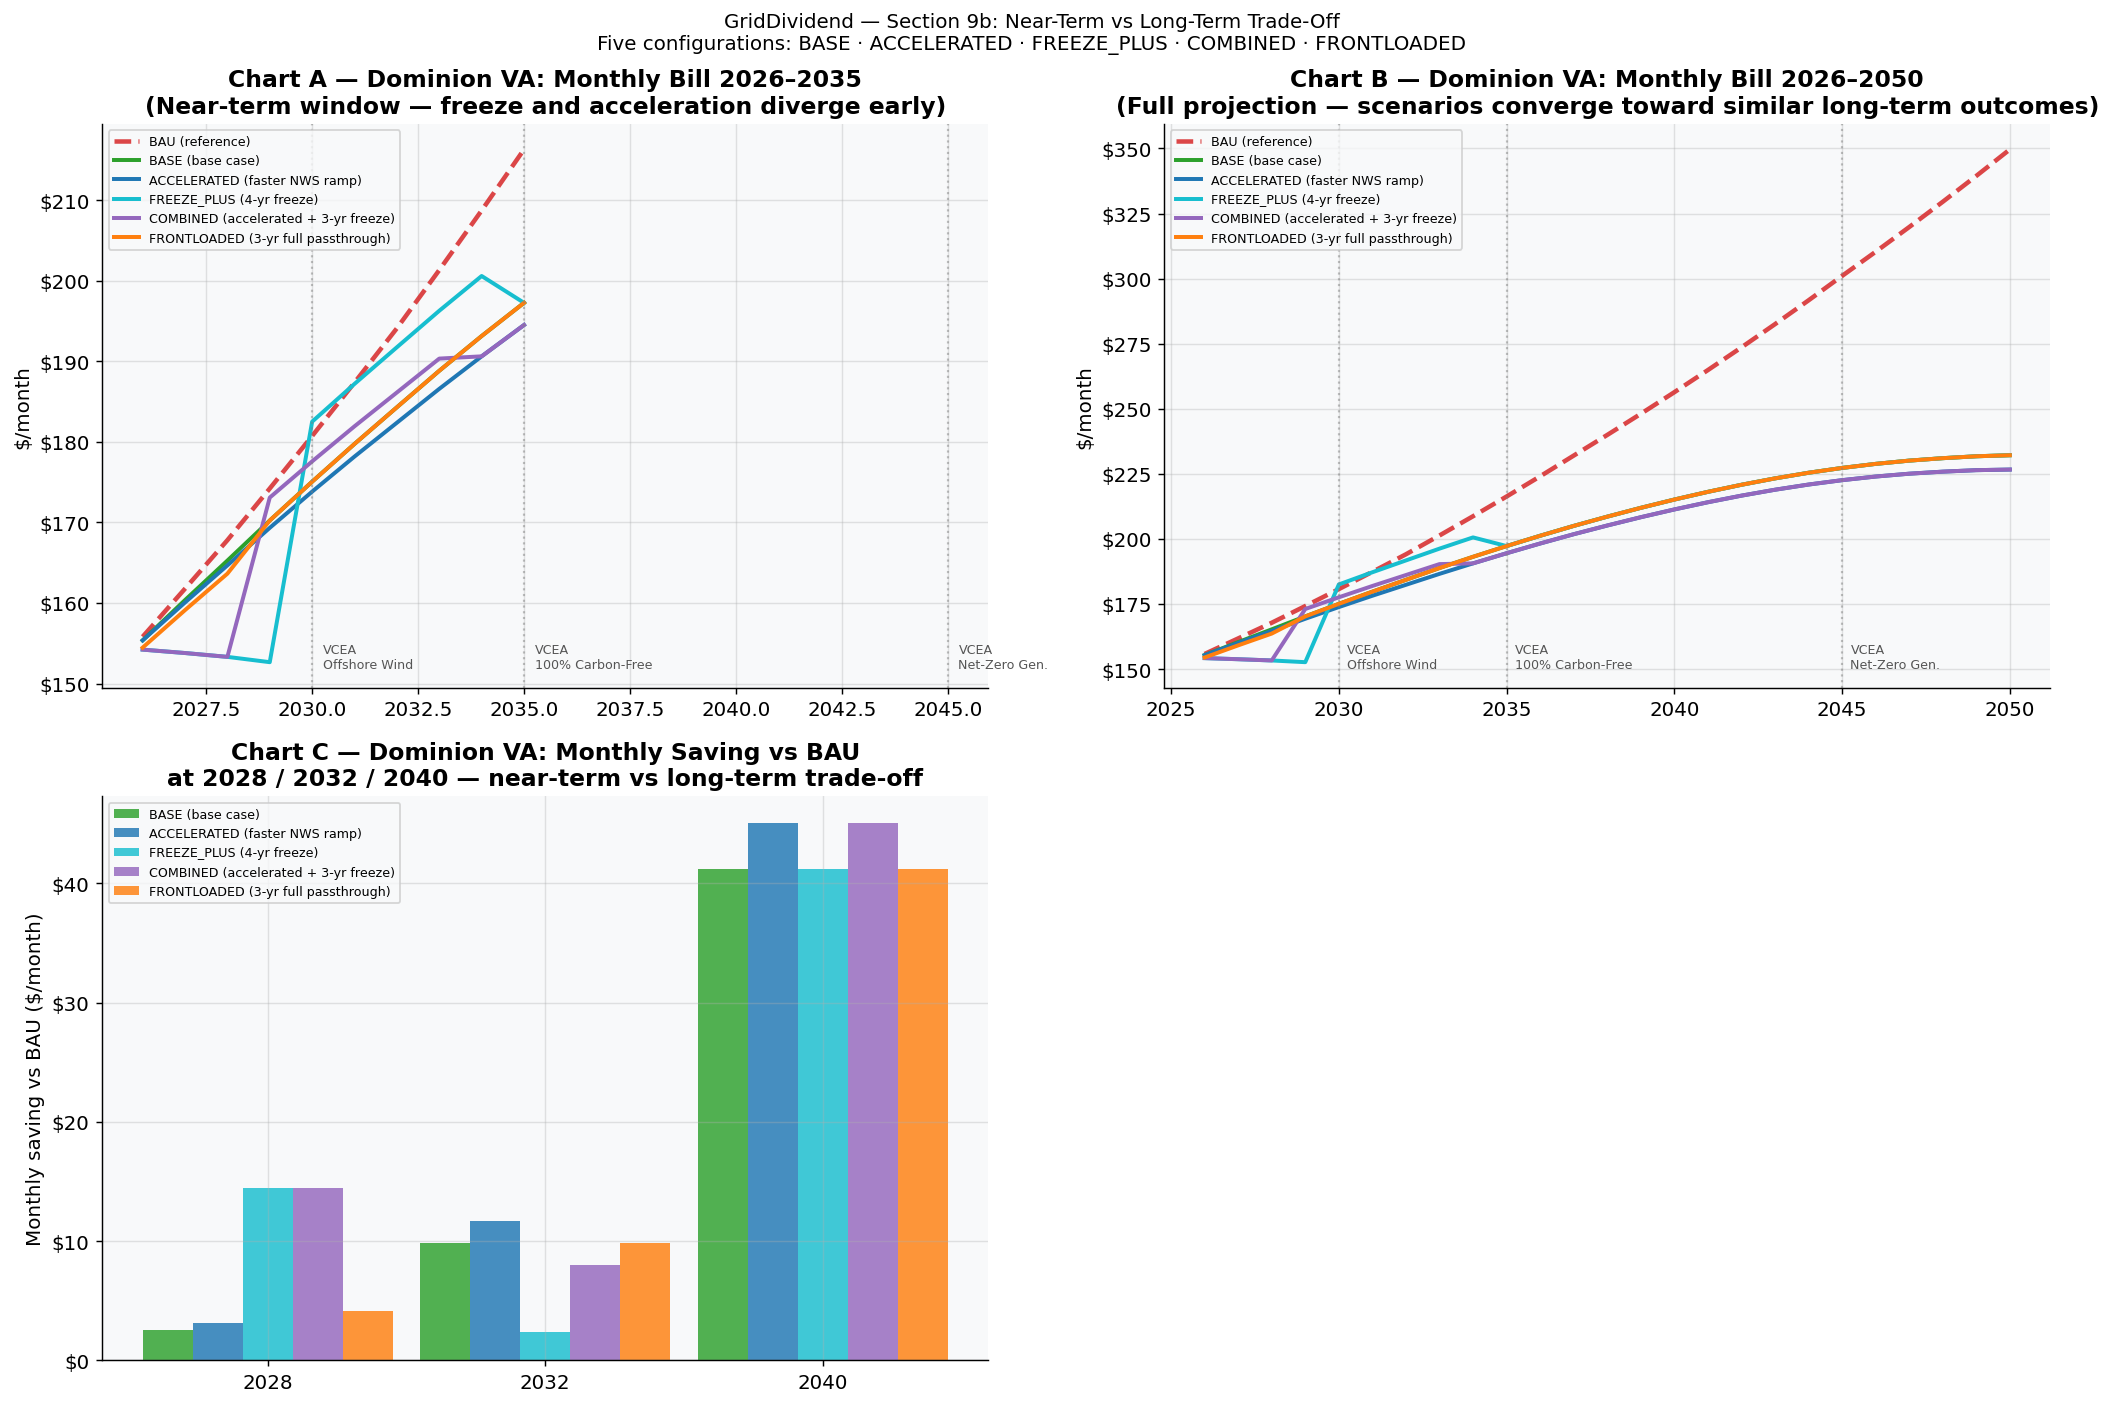

In [14]:
# ============================================================
# SECTION 9b: NEAR-TERM VS LONG-TERM TRADE-OFF — CHARTS
# Chart A: Con Edison monthly bill trajectories, 2026-2035 (near-term window)
# Chart B: Con Edison monthly bill trajectories, 2026-2050 (full projection)
# Chart C: Monthly saving vs BAU at 2028/2032/2040, both utilities side by side
# ============================================================

k_main    = utilities_to_run[0]
name_main = UTILITIES[k_main]['short_name']
bau_main  = results[k_main]['bau']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'GridDividend — Section 9b: Near-Term vs Long-Term Trade-Off\n'
    'Five configurations: BASE · ACCELERATED · FREEZE_PLUS · COMBINED · FRONTLOADED',
    fontsize=11)

# ── Chart A: near-term window 2026–2035 ──────────────────────────────────────
ax = axes[0, 0]
bau_a = bau_main[bau_main['year'] <= 2035]
ax.plot(bau_a['year'], bau_a['avg_monthly_bill'],
        color=C['bau'], lw=2.5, ls='--', alpha=0.85, label='BAU (reference)')
for sname, sdef in SCENARIO_DEFS.items():
    df_a = scenario_results[k_main][sname]
    df_a = df_a[df_a['year'] <= 2035]
    ax.plot(df_a['year'], df_a['avg_monthly_bill'],
            color=sdef['colour'], lw=2.2, label=sdef['label'])
vlines(ax)
ax.set_title(f'Chart A — {name_main}: Monthly Bill 2026–2035\n'
             '(Near-term window — freeze and acceleration diverge early)')
ax.set_ylabel('$/month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=7, loc='upper left')

# ── Chart B: full projection 2026–2050 ───────────────────────────────────────
ax = axes[0, 1]
ax.plot(YEARS, bau_main['avg_monthly_bill'],
        color=C['bau'], lw=2.5, ls='--', alpha=0.85, label='BAU (reference)')
for sname, sdef in SCENARIO_DEFS.items():
    df_b = scenario_results[k_main][sname]
    ax.plot(df_b['year'], df_b['avg_monthly_bill'],
            color=sdef['colour'], lw=2.2, label=sdef['label'])
vlines(ax)
ax.set_title(f'Chart B — {name_main}: Monthly Bill 2026–2050\n'
             '(Full projection — scenarios converge toward similar long-term outcomes)')
ax.set_ylabel('$/month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=7, loc='upper left')

# ── Chart C: savings vs BAU at 2028 / 2032 / 2040, both utilities ────────────
snapshots = [2028, 2032, 2040]
x_pos     = np.arange(len(snapshots))
bar_w     = max(0.10, 0.90 / len(SCENARIO_DEFS))

for ci, k in enumerate(utilities_to_run[:2]):
    ax     = axes[1, ci]
    bau_df = results[k]['bau']
    for si, (sname, sdef) in enumerate(SCENARIO_DEFS.items()):
        sh_df   = scenario_results[k][sname]
        savings = []
        for yr in snapshots:
            bau_bill = bau_df[bau_df['year'] == yr].iloc[0]['avg_monthly_bill']
            sh_bill  = sh_df[sh_df['year']  == yr].iloc[0]['avg_monthly_bill']
            savings.append(max(0.0, bau_bill - sh_bill))
        offset = (si - (len(SCENARIO_DEFS) - 1) / 2) * bar_w
        ax.bar(x_pos + offset, savings, bar_w,
               color=sdef['colour'], label=sdef['label'], alpha=0.82)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(y) for y in snapshots])
    ax.set_ylabel('Monthly saving vs BAU ($/month)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
    ax.set_title(f'Chart C — {UTILITIES[k]["short_name"]}: Monthly Saving vs BAU\n'
                 'at 2028 / 2032 / 2040 — near-term vs long-term trade-off')
    ax.legend(fontsize=7)

if len(utilities_to_run) < 2:
    axes[1, 1].set_visible(False)

plt.tight_layout()
plt.savefig('charts/chart9b_nearterm_tradeoff.png', bbox_inches='tight', dpi=130)
plt.show()


In [15]:
# ============================================================
# SECTION 9b: NEAR-TERM VS LONG-TERM TRADE-OFF — SUMMARY TABLES
# Separate tables for each utility.
# Per scenario: bills at 2028/2035/2050, first year savings exceed
# $10/month vs BAU, and cumulative savings to 2050.
# ============================================================

def print_scenario_table(k):
    name   = UTILITIES[k]['short_name']
    bau_df = results[k]['bau']
    hdr = (f"  {'Scenario':<16} {'2028 $/mo':>10} {'2035 $/mo':>10} "
           f"{'2050 $/mo':>10} {'$10+/mo yr':>11} {'Cum $B':>8}")
    kwh_9b = UTILITIES[k].get('residential_kwh_month', 1000)
    print(f'Section 9b — {name} Scenario Summary Table ({kwh_9b:,.0f} kWh/month benchmark)')
    print(hdr)
    print('  ' + '-' * (len(hdr) - 2))
    for sname, sdef in SCENARIO_DEFS.items():
        df  = scenario_results[k][sname]
        b28 = df[df['year'] == 2028].iloc[0]['avg_monthly_bill']
        b35 = df[df['year'] == 2035].iloc[0]['avg_monthly_bill']
        b50 = df[df['year'] == 2050].iloc[0]['avg_monthly_bill']
        first_10 = '—'
        for yr in YEARS:
            bau_bill = bau_df[bau_df['year'] == yr].iloc[0]['avg_monthly_bill']
            sh_bill  = df[df['year'] == yr].iloc[0]['avg_monthly_bill']
            if bau_bill - sh_bill > 10:
                first_10 = str(yr)
                break
        cum = np.sum(
            (bau_df['avg_annual_bill'].values - df['avg_annual_bill'].values)
            * df['customers'].values
        ) / 1e9
        print(f'  {sname:<16} {b28:>9.1f}  {b35:>9.1f}  {b50:>9.1f}  '
              f'{first_10:>10}  {cum:>6.1f}B')
    print()

for k in utilities_to_run:
    print_scenario_table(k)


Section 9b — Dominion VA Scenario Summary Table (1,000 kWh/month benchmark)
  Scenario          2028 $/mo  2035 $/mo  2050 $/mo  $10+/mo yr   Cum $B
  ----------------------------------------------------------------------
  BASE                 165.3      197.2      232.2        2033    38.1B
  ACCELERATED          164.7      194.5      226.6        2032    41.0B
  FREEZE_PLUS          153.3      197.2      232.2        2028    38.1B
  COMBINED             153.3      194.5      226.6        2028    41.0B
  FRONTLOADED          163.6      197.2      232.2        2033    38.2B



$10/month threshold year by NWS ramp length (BASE params)
   Ramp yrs   Dominion VA
  ------------------------
          5          2032
          6          2032
          7          2033
          8          2033
          9          2033 ◄ BASE
         10          2033
         11          2033
         12          2033
         13          2033
         14          2033
         15          2033


Saved: charts_article/chart6_ramp_sensitivity.png


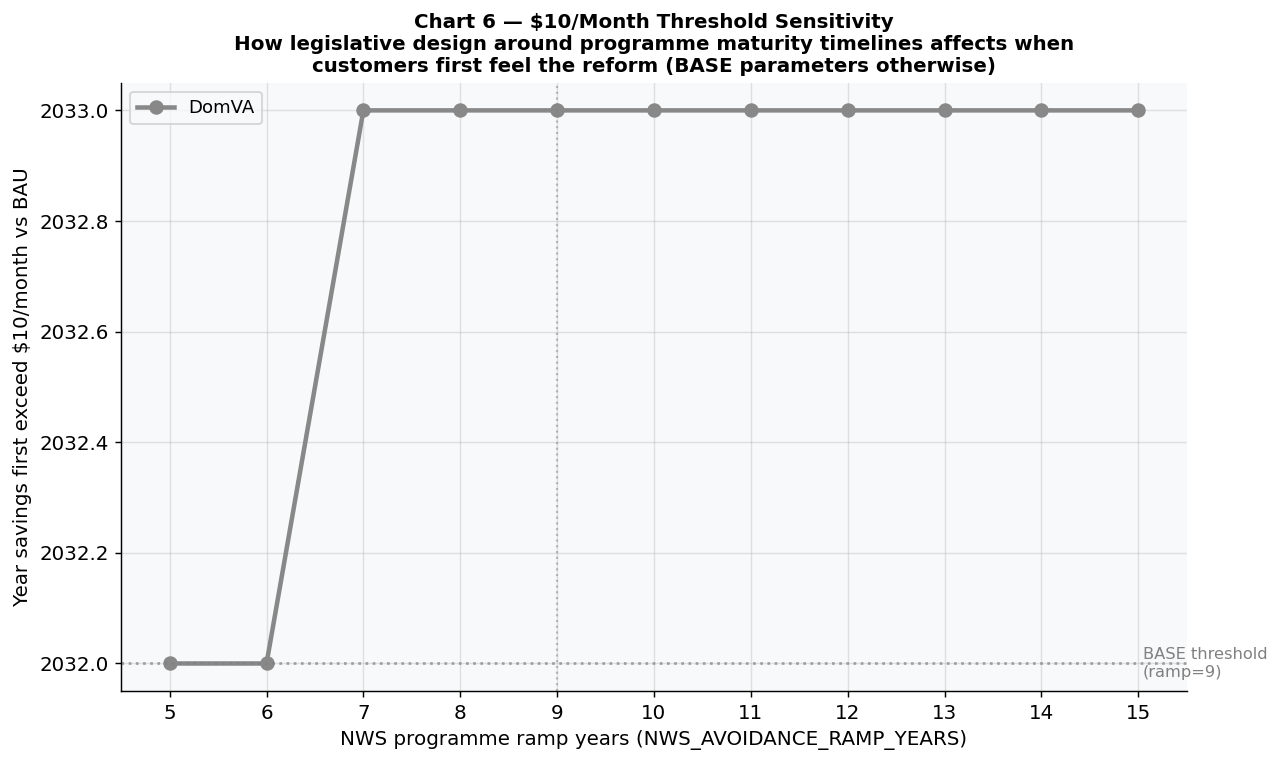

In [16]:
# ============================================================
# SECTION 9b (CONTINUED): $10/MONTH THRESHOLD RAMP SENSITIVITY
# Sweeps NWS_AVOIDANCE_RAMP_YEARS 5→15, BASE case params otherwise.
# For each ramp length: first year monthly savings vs BAU exceed $10/mo.
# ============================================================

ramp_range = list(range(5, 16))   # 5 to 15 inclusive
ramp_threshold = {k: [] for k in utilities_to_run}

for ramp_yrs in ramp_range:
    cfg = {**MODEL_CONFIG, 'NWS_AVOIDANCE_RAMP_YEARS': ramp_yrs}
    for k in utilities_to_run:
        p      = utility_data[k]
        bau_df = results[k]['bau']
        sh     = project(p, 'shared', False, config=cfg)
        # Apply same capacity pass-through as run_named_scenario BASE
        cap_cost_start = (CAPACITY_COST_START[k]
                          if isinstance(CAPACITY_COST_START, dict) else CAPACITY_COST_START)
        pt_m = []
        for yr in YEARS:
            b_row = bau_df[bau_df['year']==yr].iloc[0]
            s_row = sh[sh['year']==yr].iloc[0]
            peak_red = max(0.0, b_row['peak_mw'] - s_row['peak_mw'])
            cap_c    = cap_cost_start * (1 + CAPACITY_COST_GROWTH)**(yr-2026)
            saving_m = peak_red * cap_c
            monthly_red = (saving_m*(1-UTILITY_SAVINGS_SHARE)*1e6) / (s_row['customers']*12)
            pt_m.append(monthly_red)
        pt_df = pd.DataFrame({'year': YEARS, 'pt': pt_m})
        sh = sh.merge(pt_df, on='year', how='left')
        sh['avg_monthly_bill'] -= sh['pt']
        threshold_yr = None
        for yr in YEARS:
            bau_bill = bau_df[bau_df['year']==yr].iloc[0]['avg_monthly_bill']
            sh_bill  = sh[sh['year']==yr].iloc[0]['avg_monthly_bill']
            if bau_bill - sh_bill > 10:
                threshold_yr = yr
                break
        ramp_threshold[k].append(threshold_yr if threshold_yr else 2051)

# Print results table
print('$10/month threshold year by NWS ramp length (BASE params)')
print(f"  {'Ramp yrs':>9}", end='')
for k in utilities_to_run:
    print(f"  {UTILITIES[k]['short_name']:>12}", end='')
print()
print('  ' + '-' * (10 + 14 * len(utilities_to_run)))
for i, r in enumerate(ramp_range):
    marker = ' ◄ BASE' if r == 9 else ''
    print(f"  {r:>9}", end='')
    for k in utilities_to_run:
        t = ramp_threshold[k][i]
        print(f"  {t if t < 2051 else '>2050':>12}", end='')
    print(marker)

# Chart 6: ramp sensitivity
import os; os.makedirs('charts_article', exist_ok=True)

fig6, ax6 = plt.subplots(figsize=(10, 6))
util_styles = {'ConEd': ('-', '#1f77b4', 'Con Edison'),
               'RGE':   ('--', '#d62728', 'RG\u0026E')}
for k in utilities_to_run:
    ls, col, lbl = util_styles.get(k, ('-', '#888888', k))
    vals = [t if t < 2051 else None for t in ramp_threshold[k]]
    ax6.plot(ramp_range, vals, color=col, ls=ls, lw=2.5, marker='o', ms=7, label=lbl)
ax6.axhline(2032, color='gray', ls=':', lw=1.5, alpha=0.7)
ax6.text(15.05, 2032, 'BASE threshold\n(ramp=9)', fontsize=9, va='center', color='gray')
ax6.axvline(9, color='gray', ls=':', lw=1.2, alpha=0.5)
ax6.set_xlabel('NWS programme ramp years (NWS_AVOIDANCE_RAMP_YEARS)', fontsize=11)
ax6.set_ylabel('Year savings first exceed $10/month vs BAU', fontsize=11)
ax6.set_title('Chart 6 — $10/Month Threshold Sensitivity\n'
              'How legislative design around programme maturity timelines affects when\n'
              'customers first feel the reform (BASE parameters otherwise)',
              fontsize=11)
ax6.set_xticks(ramp_range)
ax6.set_xlim(4.5, 15.5)
ax6.legend(fontsize=10)
fig6.tight_layout()
fname6 = 'charts_article/chart6_ramp_sensitivity.png'
fig6.savefig(fname6, dpi=300, bbox_inches='tight')
print(f'Saved: {fname6}')
plt.show()


## Section 9c: Article Charts

Six publication-quality charts saved to `charts_article/` at 300 dpi, plus a ramp sensitivity analysis for Section 9b.

**Chart 1:** Near-term bill savings vs BAU, Con Edison, 2026–2035  
**Chart 2:** Full-projection bill savings vs BAU, Con Edison, 2026–2050  
**Chart 3:** Near-term bill savings vs BAU, RG&E, 2026–2035  
**Chart 4:** Full-projection bill savings vs BAU, RG&E, 2026–2050  
**Chart 5:** Milestone bar chart — savings at 2028 / 2032 / 2040, both utilities  
**Chart 6:** Ramp sensitivity — year $10/month threshold reached vs NWS ramp years

Saved: charts_article/chart1_domva_nearterm.png


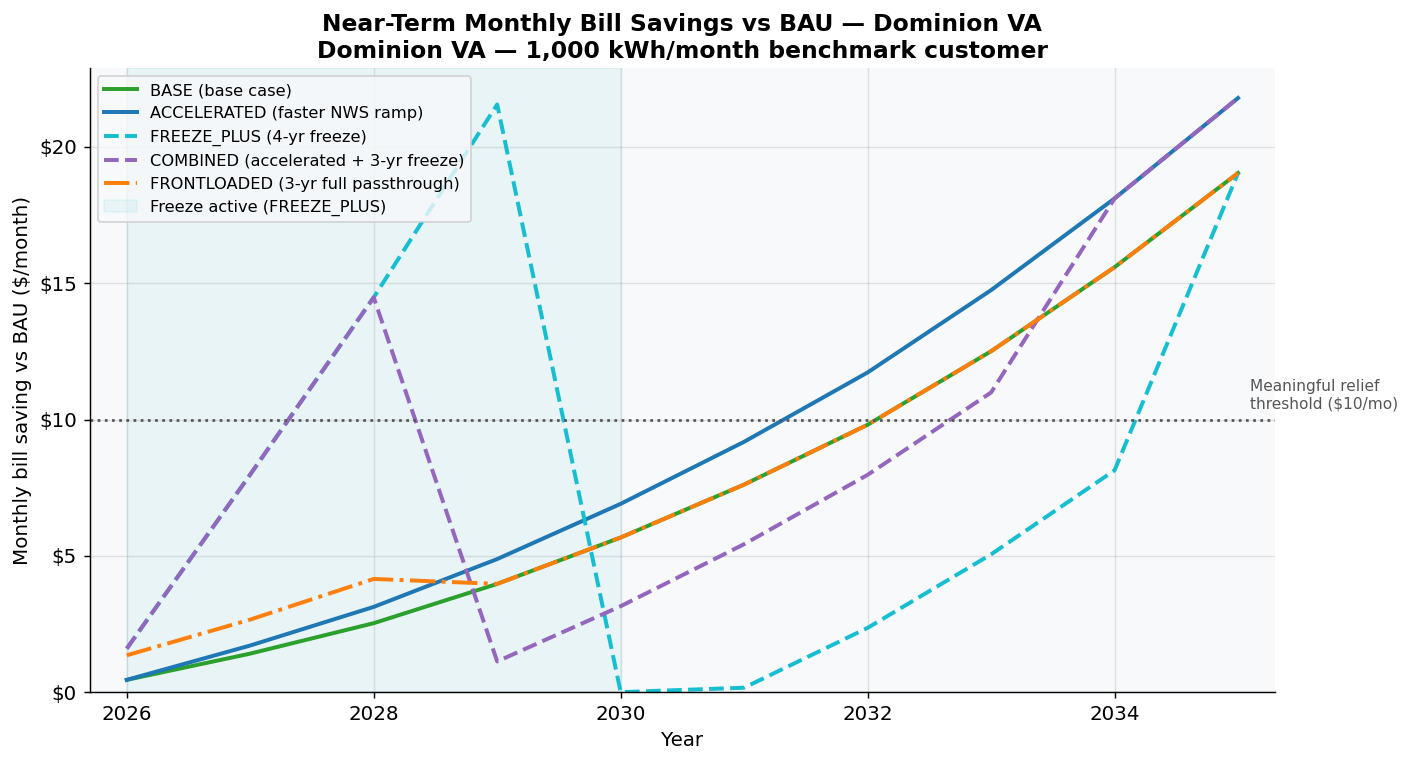

Saved: charts_article/chart2_domva_full.png


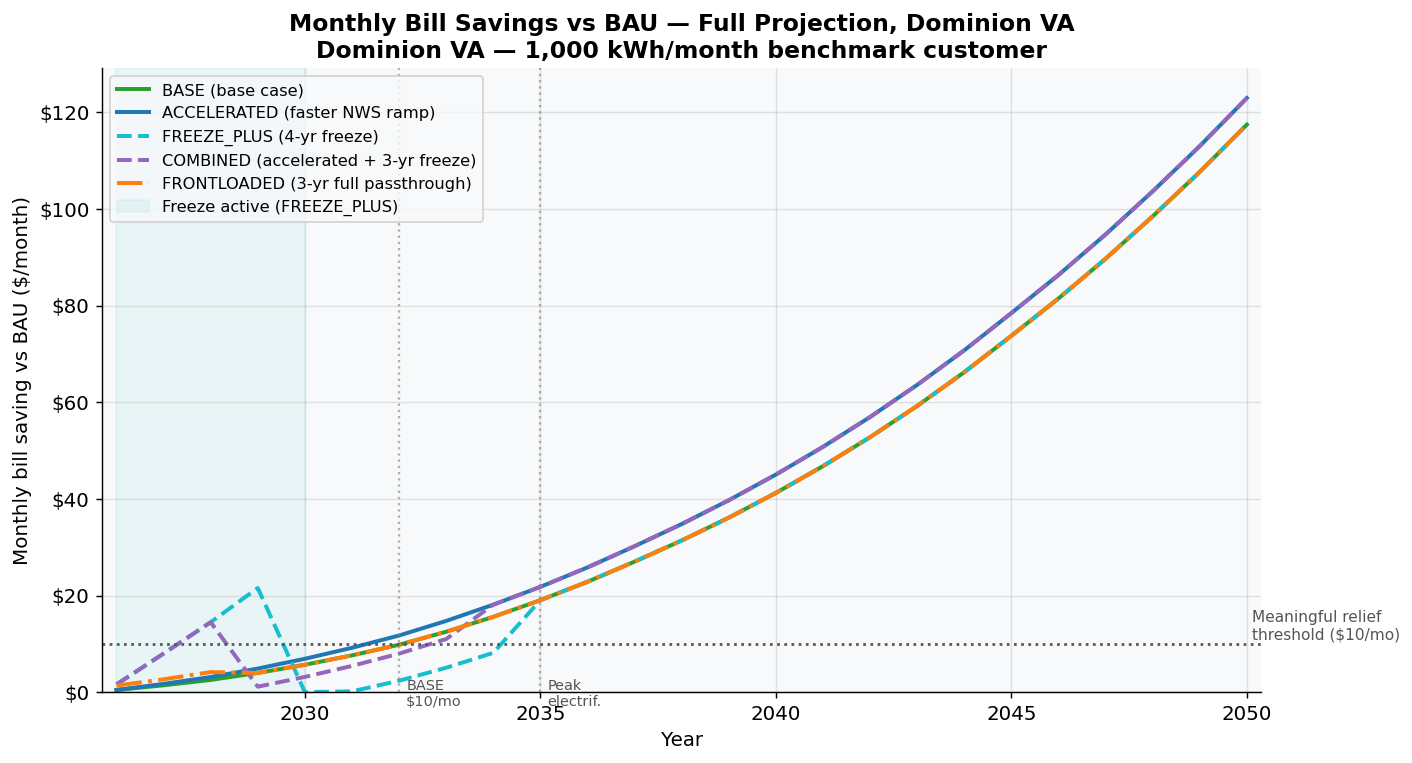

Saved: charts_article/chart5_milestone_bars.png


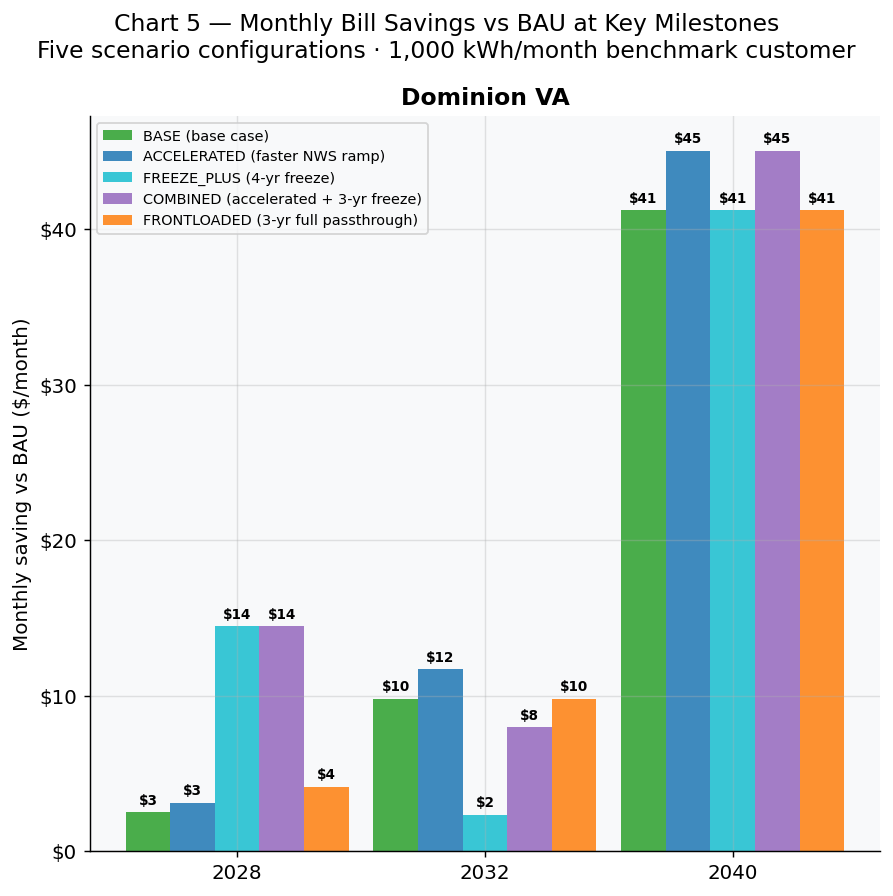

In [17]:
# ============================================================
# SECTION 9c: ARTICLE CHARTS 1-5
# All saved to charts_article/ at 300 dpi.
# Charts 1-4: monthly savings vs BAU (floor 0), near-term and full.
# Chart 5: bar chart at milestone years, both utilities.
# ============================================================

import os; os.makedirs('charts_article', exist_ok=True)

SC = {sname: sdef for sname, sdef in SCENARIO_DEFS.items()}
SC_LINES = {
    'BASE':        ('-',   SC['BASE']['colour'],        'BASE (base case)'),
    'ACCELERATED': ('-',   SC['ACCELERATED']['colour'], 'ACCELERATED (faster NWS ramp)'),
    'FREEZE_PLUS': ('--',  SC['FREEZE_PLUS']['colour'], 'FREEZE_PLUS (4-yr freeze)'),
    'COMBINED':    ('--',  SC['COMBINED']['colour'],    'COMBINED (accelerated + 3-yr freeze)'),
    'FRONTLOADED': ('-.',  SC['FRONTLOADED']['colour'], 'FRONTLOADED (3-yr full passthrough)'),
}

def savings_series(k, sname, years=None):
    """Monthly savings vs BAU, floored at 0, for given years."""
    if years is None: years = YEARS
    bau_df = results[k]['bau']
    sh_df  = scenario_results[k][sname]
    savs = []
    for yr in years:
        b = bau_df[bau_df['year']==yr].iloc[0]['avg_monthly_bill']
        s = sh_df[sh_df['year']==yr].iloc[0]['avg_monthly_bill']
        savs.append(max(0.0, b - s))
    return savs

def make_savings_chart(k, years, title, fname, extra_vlines=None):
    """Charts 1-4 template: savings vs BAU over a year range."""
    name = UTILITIES[k]['short_name']
    # FREEZE_PLUS freeze end year (2026 + RATE_FREEZE_YEARS = 2030)
    freeze_end_yr = 2026 + SC['FREEZE_PLUS']['params'].get('RATE_FREEZE_YEARS', RATE_FREEZE_YEARS)

    fig, ax = plt.subplots(figsize=(11, 6))
    for sname, (ls, col, lbl) in SC_LINES.items():
        svs = savings_series(k, sname, years)
        ax.plot(years, svs, color=col, ls=ls, lw=2.2, label=lbl)

    # $10/month reference line
    ax.axhline(10, color='#555', ls=':', lw=1.5)
    ax.text(years[-1] + 0.1, 10.3, 'Meaningful relief\nthreshold ($10/mo)',
            fontsize=8.5, va='bottom', color='#555')

    # Shade freeze-active period for FREEZE_PLUS
    freeze_shade_end = min(freeze_end_yr, years[-1])
    if freeze_shade_end > years[0]:
        ax.axvspan(years[0], freeze_shade_end, alpha=0.07,
                   color=SC['FREEZE_PLUS']['colour'], label='Freeze active (FREEZE_PLUS)')

    # Extra vertical reference lines
    if extra_vlines:
        for yr, lbl in extra_vlines.items():
            if years[0] <= yr <= years[-1]:
                ax.axvline(yr, color='gray', ls=':', lw=1.3, alpha=0.6)
                ylo, yhi = ax.get_ylim()
                ax.text(yr + 0.15, ylo + (yhi-ylo)*0.02, lbl,
                        fontsize=8, color='#555', va='bottom')

    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Monthly bill saving vs BAU ($/month)', fontsize=11)
    kwh_9c = UTILITIES[k].get('residential_kwh_month', 1000)
    ax.set_title(f'{title}\n{name} — {kwh_9c:,.0f} kWh/month benchmark customer', fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9, loc='upper left')
    fig.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()

# ── Charts 1–4 ───────────────────────────────────────────────────────────────
near = [y for y in YEARS if y <= 2035]
full = YEARS
vlines_full = {2032: 'BASE\n$10/mo', 2035: 'Peak\nelectrif.'}

k_primary = utilities_to_run[0]
name_primary = UTILITIES[k_primary]['short_name']

make_savings_chart(
    k_primary, near,
    f'Near-Term Monthly Bill Savings vs BAU — {name_primary}',
    f'charts_article/chart1_{k_primary.lower()}_nearterm.png')

make_savings_chart(
    k_primary, full,
    f'Monthly Bill Savings vs BAU — Full Projection, {name_primary}',
    f'charts_article/chart2_{k_primary.lower()}_full.png',
    extra_vlines=vlines_full)

if 'RGE' in utilities_to_run:
    make_savings_chart(
        'RGE', near,
        'Near-Term Monthly Bill Savings vs BAU — RG\u0026E',
        'charts_article/chart3_rge_nearterm.png')

    make_savings_chart(
        'RGE', full,
        'Monthly Bill Savings vs BAU — Full Projection, RG\u0026E',
        'charts_article/chart4_rge_full.png',
        extra_vlines=vlines_full)

# ── Chart 5: bar chart — milestone savings, both utilities ────────────────────
snapshots  = [2028, 2032, 2040]
x_pos      = np.arange(len(snapshots))
snames     = list(SC.keys())
bar_w      = max(0.10, 0.90 / len(snames))
n_util     = min(2, len(utilities_to_run))

fig5, axes5 = plt.subplots(1, n_util, figsize=(7 * n_util, 7), sharey=False)
if n_util == 1: axes5 = [axes5]

for ci, k in enumerate(utilities_to_run[:n_util]):
    ax = axes5[ci]
    bau_df = results[k]['bau']
    for si, sname in enumerate(snames):
        ls, col, lbl = SC_LINES[sname]
        sh_df   = scenario_results[k][sname]
        savings = []
        for yr in snapshots:
            b = bau_df[bau_df['year']==yr].iloc[0]['avg_monthly_bill']
            s = sh_df[sh_df['year']==yr].iloc[0]['avg_monthly_bill']
            savings.append(max(0.0, b - s))
        offset = (si - (len(snames) - 1) / 2) * bar_w
        bars = ax.bar(x_pos + offset, savings, bar_w, color=col,
                      label=lbl, alpha=0.85)
        for bar, val in zip(bars, savings):
            if val >= 0.5:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'${val:.0f}', ha='center', va='bottom', fontsize=7.5,
                        fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(y) for y in snapshots], fontsize=11)
    ax.set_ylabel('Monthly saving vs BAU ($/month)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
    ax.set_title(f'{UTILITIES[k]["short_name"]}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

kwh_5 = UTILITIES[utilities_to_run[0]].get('residential_kwh_month', 1000)
fig5.suptitle(
    'Chart 5 — Monthly Bill Savings vs BAU at Key Milestones\n'
    f'Five scenario configurations · {kwh_5:,.0f} kWh/month benchmark customer',
    fontsize=13)
fig5.tight_layout()
fname5 = 'charts_article/chart5_milestone_bars.png'
fig5.savefig(fname5, dpi=300, bbox_inches='tight')
print(f'Saved: {fname5}')
plt.show()


Saved: charts_article/chart7_deferral_sensitivity.png


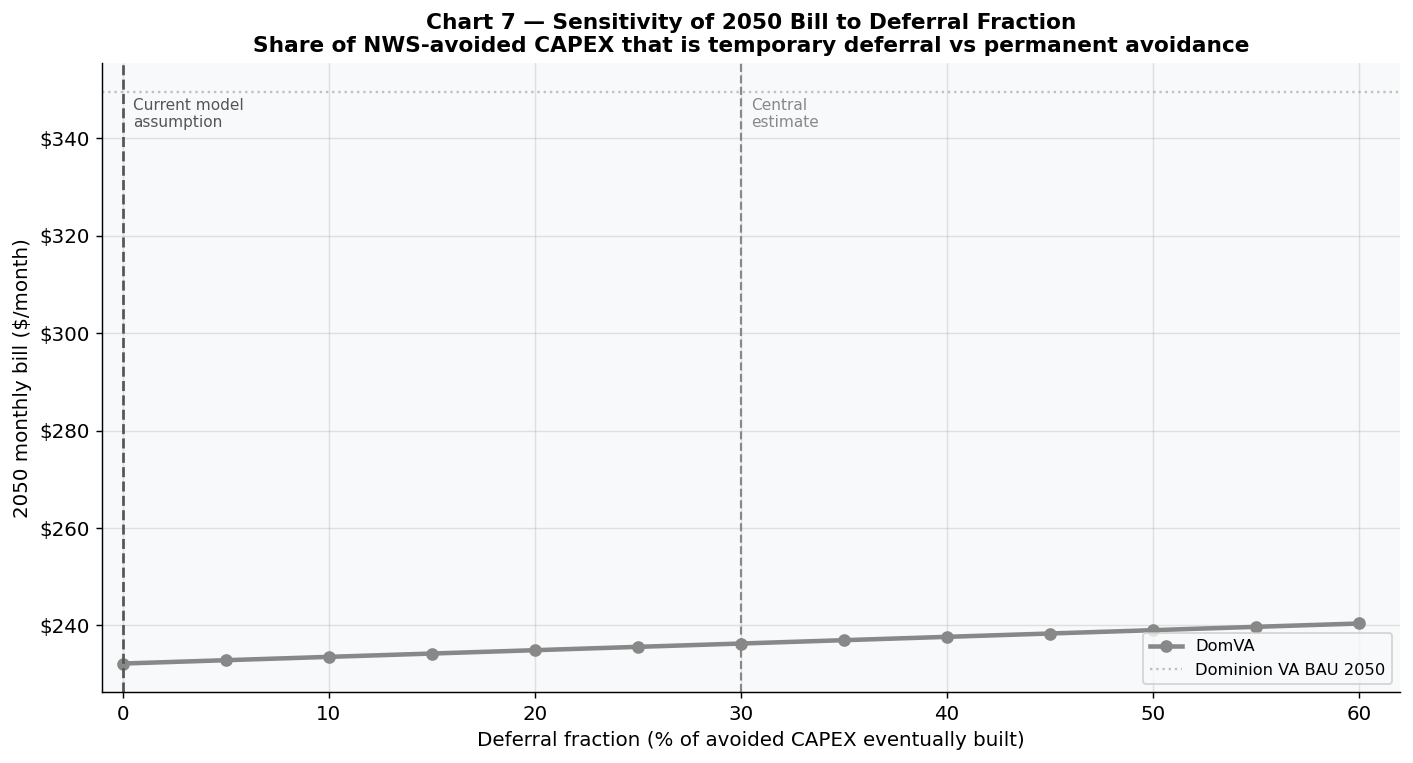


Deferral fraction sensitivity — 2050 monthly bill ($/month)
    Deferral %  Dominion VA
  --------------------------
            0%  $     232  ← current model
            5%  $     233
           10%  $     234
           15%  $     234
           20%  $     235
           25%  $     236
           30%  $     236  ← central estimate
           35%  $     237
           40%  $     238
           45%  $     238
           50%  $     239
           55%  $     240
           60%  $     240


In [18]:
# ============================================================
# SECTION 9d: DEFERRAL FRACTION SENSITIVITY
# Sweeps DEFERRAL_FRACTION 0.0 → 0.60 in steps of 0.05.
# For each value: re-runs shared savings scenario, records 2050 monthly bill.
# Saves chart7_deferral_sensitivity.png to charts_article/.
# ============================================================

import os; os.makedirs('charts_article', exist_ok=True)

deferral_range   = [round(x * 0.05, 2) for x in range(13)]  # 0.00 to 0.60
bill_2050_by_df  = {k: [] for k in utilities_to_run}

for df_val in deferral_range:
    cfg = {**MODEL_CONFIG, 'DEFERRAL_FRACTION': df_val}
    for k in utilities_to_run:
        p    = utility_data[k]
        sh   = project(p, 'shared', False, config=cfg)
        # Apply capacity pass-through (same as BASE scenario)
        bau_df_ref = results[k]['bau']
        cap_cs = (CAPACITY_COST_START[k]
                  if isinstance(CAPACITY_COST_START, dict) else CAPACITY_COST_START)
        pt_m = []
        for yr in YEARS:
            b_row = bau_df_ref[bau_df_ref['year'] == yr].iloc[0]
            s_row = sh[sh['year'] == yr].iloc[0]
            peak_red = max(0.0, b_row['peak_mw'] - s_row['peak_mw'])
            cap_c    = cap_cs * (1 + CAPACITY_COST_GROWTH) ** (yr - 2026)
            monthly_red = (peak_red * cap_c * (1 - UTILITY_SAVINGS_SHARE) * 1e6) / (
                           s_row['customers'] * 12)
            pt_m.append(monthly_red)
        pt_frame = pd.DataFrame({'year': YEARS, 'pt': pt_m})
        sh = sh.merge(pt_frame, on='year', how='left')
        sh['avg_monthly_bill'] -= sh['pt']
        b50 = sh[sh['year'] == 2050].iloc[0]['avg_monthly_bill']
        bill_2050_by_df[k].append(b50)

# ── Chart 7 ────────────────────────────────────────────────────────────────
fig7, ax7 = plt.subplots(figsize=(11, 6))

util_styles7 = {
    'ConEd': ('-',  '#1f77b4', 'Con Edison'),
    'RGE':   ('--', '#d62728', 'RG\u0026E'),
}

for k in utilities_to_run:
    ls7, col7, lbl7 = util_styles7.get(k, ('-', '#888888', k))
    ax7.plot([v * 100 for v in deferral_range], bill_2050_by_df[k],
             color=col7, ls=ls7, lw=2.5, marker='o', ms=6, label=lbl7)
    # BAU reference line
    bau_50 = results[k]['bau'][results[k]['bau']['year'] == 2050].iloc[0]['avg_monthly_bill']
    ax7.axhline(bau_50, color=col7, ls=':', lw=1.3, alpha=0.5,
                label=f'{UTILITIES[k]["short_name"]} BAU 2050')

ax7.axvline(0.0,  color='#555', ls='--', lw=1.5)
ax7.text(0.5,  ax7.get_ylim()[1] * 0.98, 'Current model\nassumption',
         fontsize=8.5, va='top', color='#555')
ax7.axvline(30.0, color='#888', ls='--', lw=1.2)
ax7.text(30.5, ax7.get_ylim()[1] * 0.98, 'Central\nestimate',
         fontsize=8.5, va='top', color='#888')

ax7.set_xlabel('Deferral fraction (% of avoided CAPEX eventually built)', fontsize=11)
ax7.set_ylabel('2050 monthly bill ($/month)', fontsize=11)
ax7.set_title(
    'Chart 7 — Sensitivity of 2050 Bill to Deferral Fraction\n'
    'Share of NWS-avoided CAPEX that is temporary deferral vs permanent avoidance',
    fontsize=12)
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax7.set_xlim(-1, 62)
ax7.legend(fontsize=9)
fig7.tight_layout()
fname7 = 'charts_article/chart7_deferral_sensitivity.png'
fig7.savefig(fname7, dpi=300, bbox_inches='tight')
print(f'Saved: {fname7}')
plt.show()

# Print summary table
print('\nDeferral fraction sensitivity — 2050 monthly bill ($/month)')
hdr = f"  {'Deferral %':>12}"
for k in utilities_to_run:
    hdr += f"  {UTILITIES[k]['short_name']:>10}"
print(hdr)
print('  ' + '-' * (14 + 12 * len(utilities_to_run)))
for i, df_val in enumerate(deferral_range):
    row = f'  {df_val*100:>11.0f}%'
    for k in utilities_to_run:
        row += f'  ${bill_2050_by_df[k][i]:>8.0f}'
    marker = '  ← current model' if df_val == 0.0 else (
             '  ← central estimate' if df_val == 0.30 else '')
    print(row + marker)

## Section 9d: The Long-Term Case — Cumulative Cost and Policy Window Analysis

These charts address the central policy question: not how much does shared savings reform save in year one, but what does it mean for what customers pay over the lifetime of the programme? The cumulative cost chart, the crossover analysis, and the policy window framing are designed to reframe the discussion from short-term relief to long-term trajectory.

Saved: charts_article/chart8_cumulative_domva.png


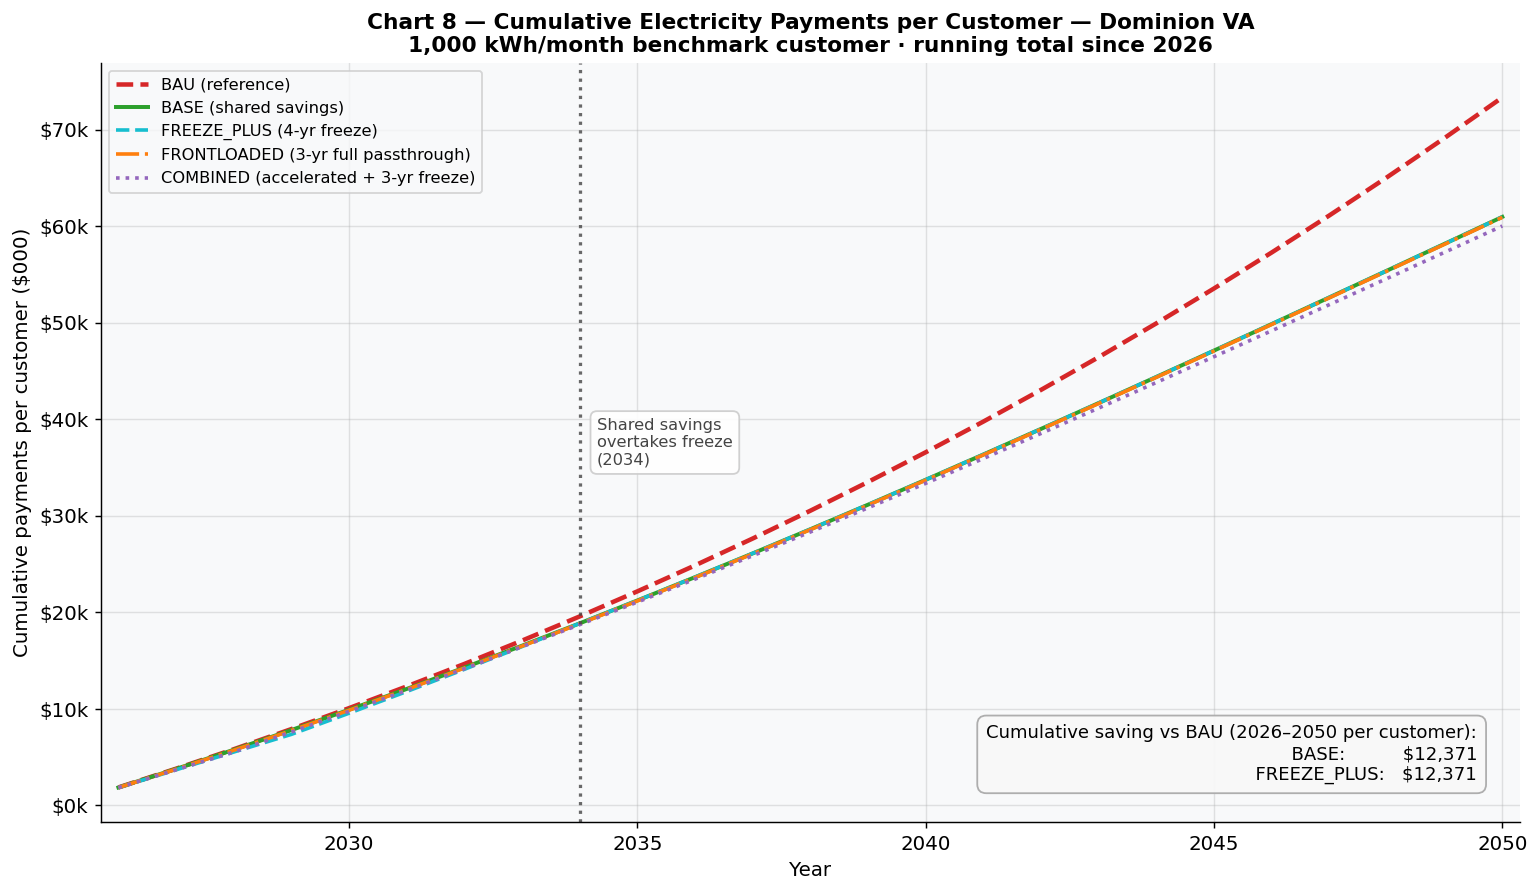

Saved: charts_article/chart9_crossover_domva.png


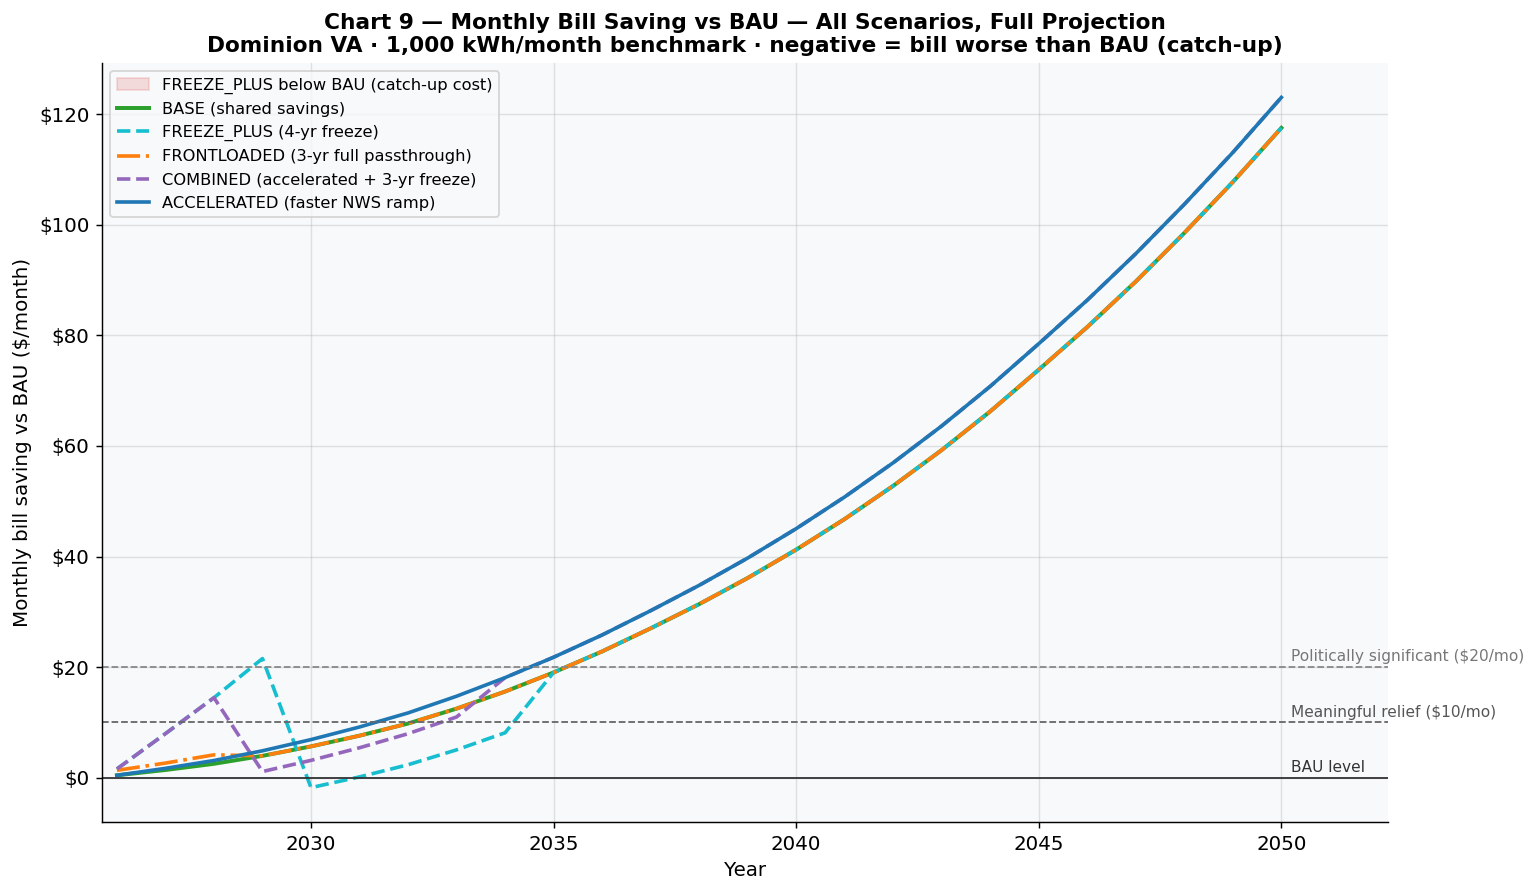

Saved: charts_article/chart10_policy_window_domva.png


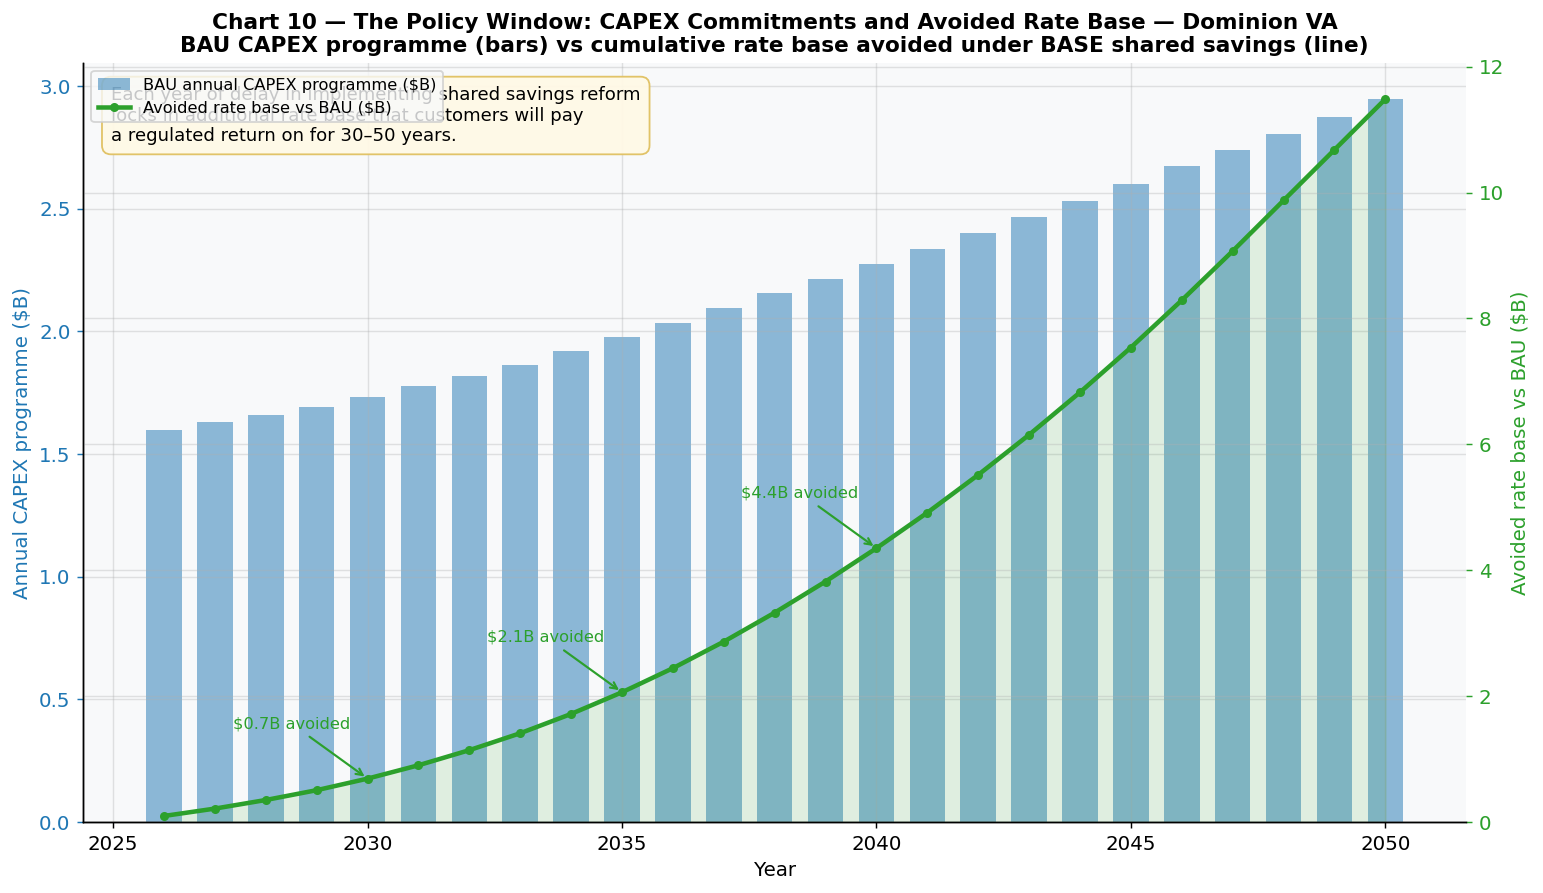

Saved: charts_article/chart11_household_impact_domva.png


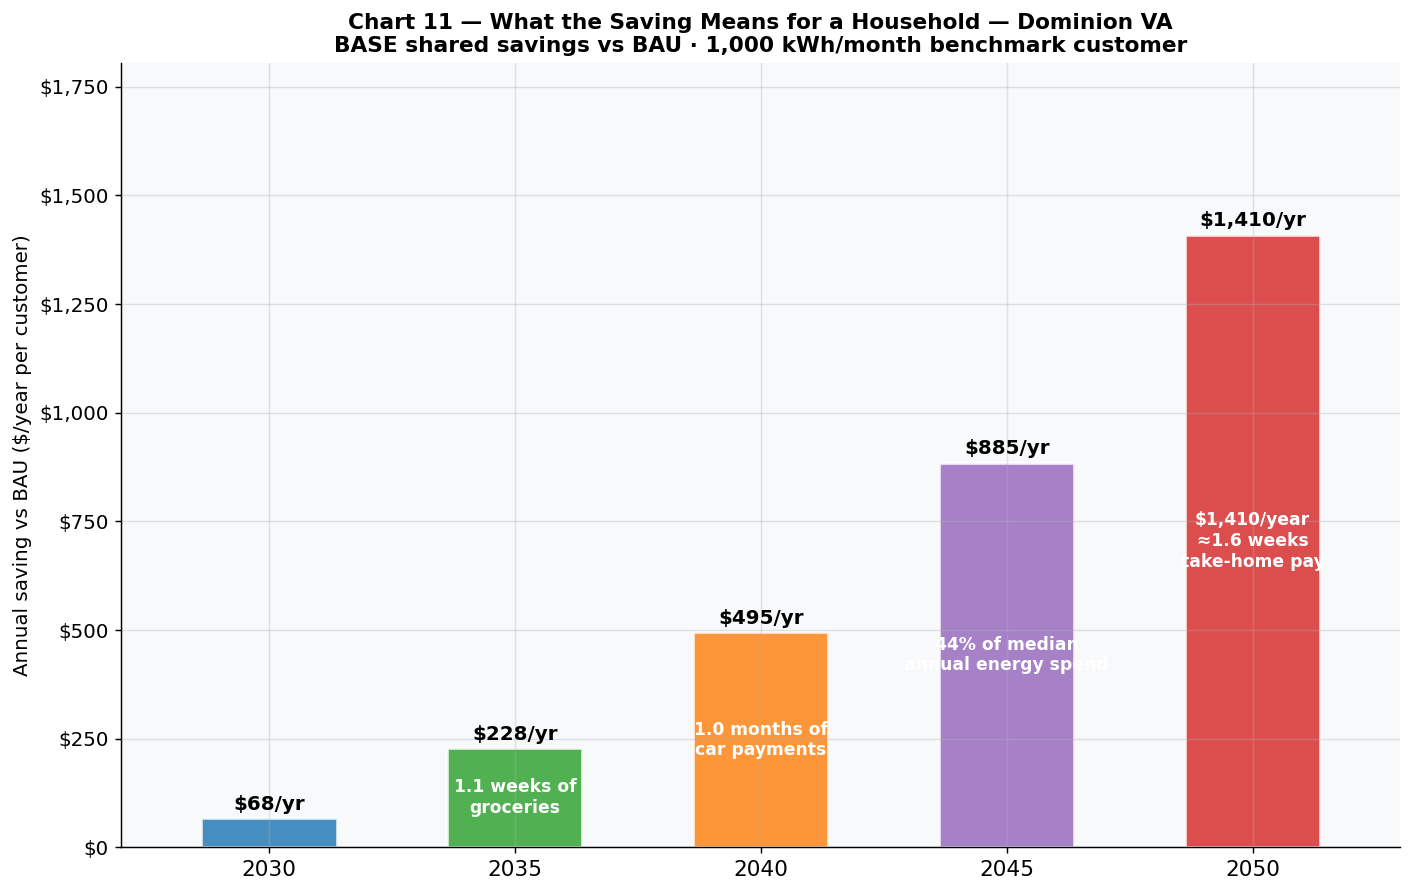


KEY NUMBERS — SECTION 9d

Crossover year (BASE cumulative cost first < FREEZE_PLUS cumulative):
  2034

Cumulative payments 2026–2050 per customer (1000 kWh/month benchmark):
  BAU:          $    73,330
  BASE:         $    60,959  (saves $12,371 vs BAU)
  FREEZE_PLUS:  $    60,959  (saves $12,371 vs BAU)

Avoided rate base BASE vs BAU ($B):
  2035: $2.1B
  2050: $11.5B

Annual saving per customer — BASE vs BAU:
  2030: $68/year   ($6/month)
  2035: $228/year   ($19/month)
  2040: $495/year   ($41/month)
  2045: $885/year   ($74/month)
  2050: $1,410/year   ($117/month)


Saved: charts_article/chart12_the_case_for_reform.png


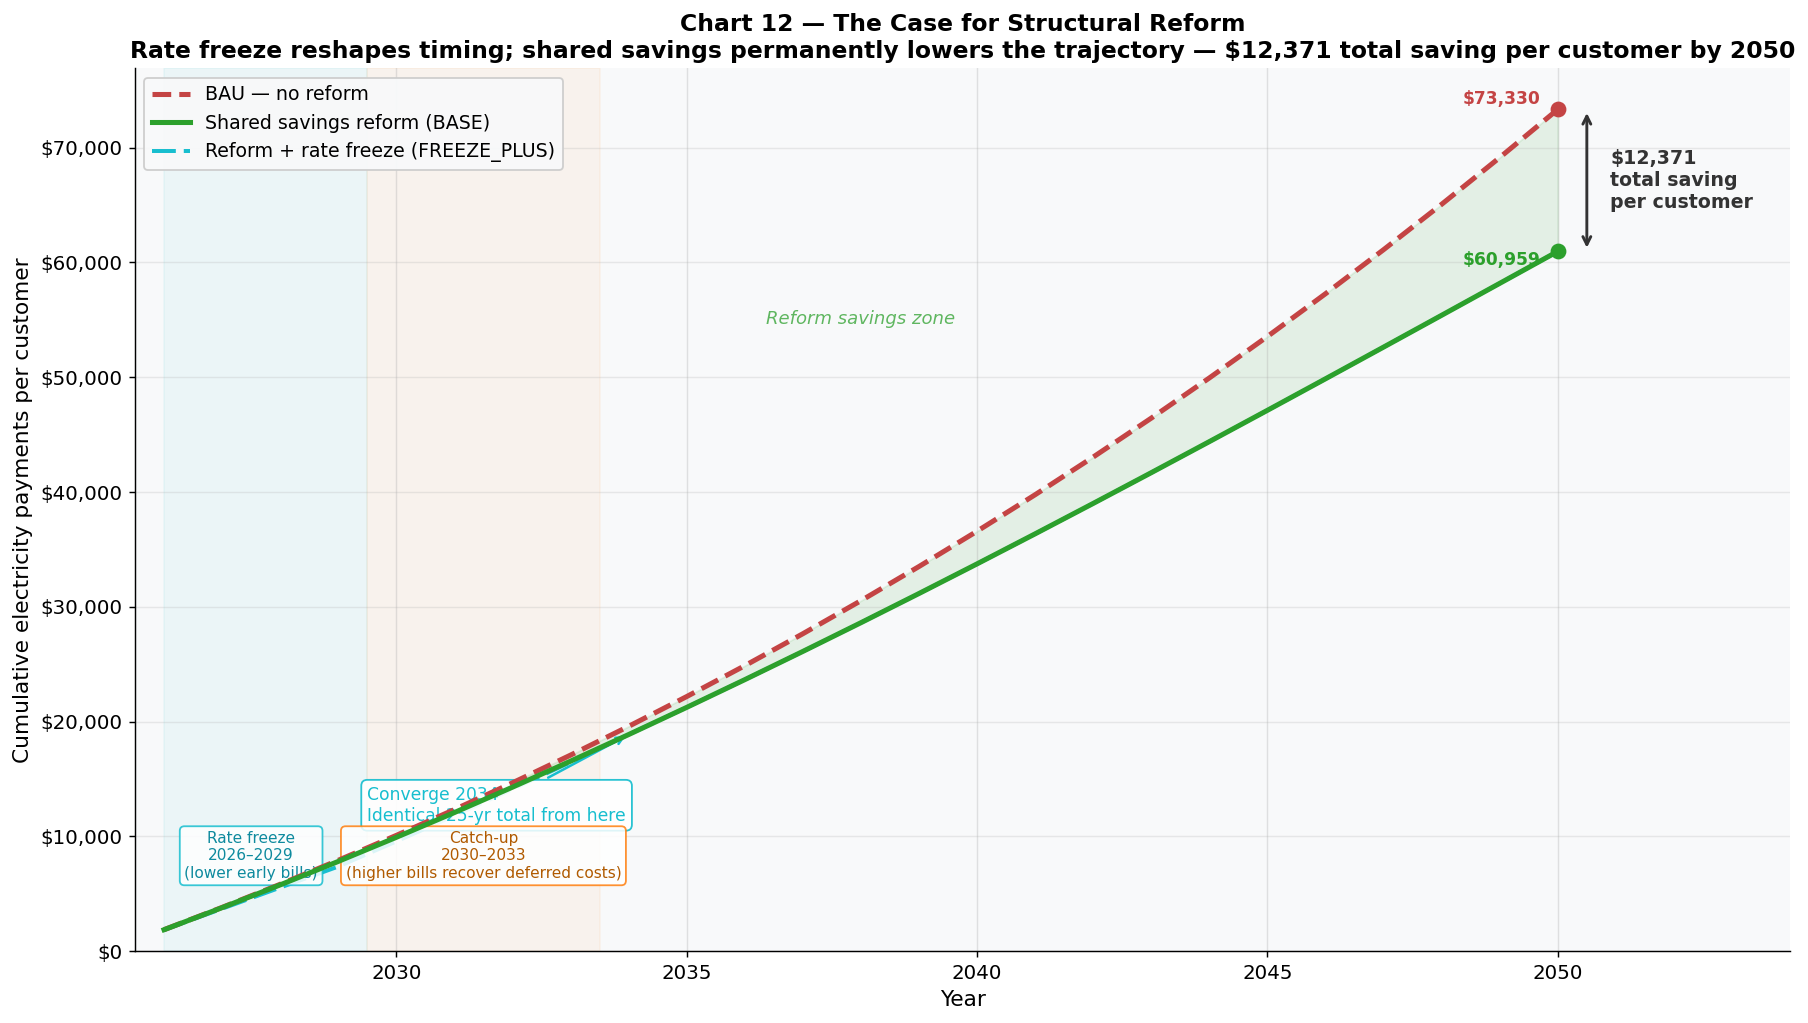

In [19]:
# ============================================================
# SECTION 9d: LONG-TERM CASE — CUMULATIVE COST AND POLICY WINDOW
# Charts 8–11 saved to charts_article/ at 300 dpi.
# ============================================================

# Explicitly scope primary utility key and params for this section
k_primary = utilities_to_run[0]
p = utility_data[k_primary]

import os
os.makedirs('charts_article', exist_ok=True)

k_9d   = utilities_to_run[0]
name_9d = UTILITIES[k_9d]['short_name']
bau_9d  = results[k_9d]['bau']
base_9d = scenario_results[k_9d]['BASE']
frzp_9d = scenario_results[k_9d]['FREEZE_PLUS']
fl_9d   = scenario_results[k_9d]['FRONTLOADED']
comb_9d = scenario_results[k_9d]['COMBINED']
accel_9d = scenario_results[k_9d]['ACCELERATED']

# ── Helpers ───────────────────────────────────────────────────────────────────
def cum_payments_9d(df):
    """Running total paid by a residential customer ($ thousands) since 2026 (usage benchmark: p['residential_kwh_month'] kWh/month)."""
    return np.cumsum(df.sort_values('year')['avg_annual_bill'].values) / 1000

def monthly_saving_9d(sc_df):
    """Monthly saving vs BAU ($/month); NOT floored — can be negative."""
    return [
        float(bau_9d[bau_9d['year'] == yr].iloc[0]['avg_monthly_bill']) -
        float(sc_df[sc_df['year'] == yr].iloc[0]['avg_monthly_bill'])
        for yr in YEARS
    ]

# Pre-compute cumulative series
cum_bau_9d  = cum_payments_9d(bau_9d)
cum_base_9d = cum_payments_9d(base_9d)
cum_frzp_9d = cum_payments_9d(frzp_9d)
cum_fl_9d   = cum_payments_9d(fl_9d)
cum_comb_9d = cum_payments_9d(comb_9d)

# Pre-compute saving series
sav_base_9d  = monthly_saving_9d(base_9d)
sav_frzp_9d  = monthly_saving_9d(frzp_9d)
sav_fl_9d    = monthly_saving_9d(fl_9d)
sav_comb_9d  = monthly_saving_9d(comb_9d)
sav_accel_9d = monthly_saving_9d(accel_9d)

# Find crossover: first year where BASE cumulative cost < FREEZE_PLUS cumulative cost
crossover_9d = None
for _i9d, _yr9d in enumerate(YEARS):
    if cum_base_9d[_i9d] < cum_frzp_9d[_i9d]:
        crossover_9d = _yr9d
        break

# ============================================================
# CHART 8: Cumulative customer payments — Con Edison
# ============================================================
fig8, ax8 = plt.subplots(figsize=(12, 7))

_cum_lines_8 = [
    (cum_bau_9d,  '--', C['bau'],                              2.5, 'BAU (reference)'),
    (cum_base_9d, '-',  SCENARIO_DEFS['BASE']['colour'],       2.2, 'BASE (shared savings)'),
    (cum_frzp_9d, '--', SCENARIO_DEFS['FREEZE_PLUS']['colour'], 2.0, 'FREEZE_PLUS (4-yr freeze)'),
    (cum_fl_9d,   '-.', SCENARIO_DEFS['FRONTLOADED']['colour'], 2.0, 'FRONTLOADED (3-yr full passthrough)'),
    (cum_comb_9d, ':',  SCENARIO_DEFS['COMBINED']['colour'],   2.0, 'COMBINED (accelerated + 3-yr freeze)'),
]
for _vals, _ls, _col, _lw, _lbl in _cum_lines_8:
    ax8.plot(YEARS, _vals, ls=_ls, color=_col, lw=_lw, label=_lbl)

# Vertical crossover line
if crossover_9d is not None:
    _ylo8, _yhi8 = ax8.get_ylim()
    ax8.axvline(crossover_9d, color='#444', ls=':', lw=1.8, alpha=0.8)
    ax8.text(crossover_9d + 0.3, _ylo8 + (_yhi8 - _ylo8) * 0.50,
             f'Shared savings\novertakes freeze\n({crossover_9d})',
             fontsize=9, color='#444', va='center',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ccc', alpha=0.90))

# Cumulative saving text box (lower right)
_csave_base = (cum_bau_9d[-1] - cum_base_9d[-1]) * 1000
_csave_frzp = (cum_bau_9d[-1] - cum_frzp_9d[-1]) * 1000
ax8.text(0.97, 0.05,
         f'Cumulative saving vs BAU (2026–2050 per customer):\n'
         f'  BASE:          ${_csave_base:,.0f}\n'
         f'  FREEZE_PLUS:   ${_csave_frzp:,.0f}',
         transform=ax8.transAxes, ha='right', va='bottom', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f8f8', edgecolor='#aaa', alpha=0.95))

ax8.set_xlabel('Year', fontsize=11)
ax8.set_ylabel('Cumulative payments per customer ($000)', fontsize=11)
ax8.set_title(
    f'Chart 8 — Cumulative Electricity Payments per Customer — {name_9d}\n'
    f'{p["residential_kwh_month"]:,.0f} kWh/month benchmark customer · running total since 2026',
    fontsize=12)
ax8.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
ax8.set_xlim(YEARS[0] - 0.3, YEARS[-1] + 0.3)
ax8.legend(fontsize=9, loc='upper left')
fig8.tight_layout()
fname8 = f'charts_article/chart8_cumulative_{k_9d.lower()}.png'
fig8.savefig(fname8, dpi=300, bbox_inches='tight')
print(f'Saved: {fname8}')
plt.show()

# ============================================================
# CHART 9: Crossover analysis — annual saving vs BAU, all scenarios
# ============================================================
fig9, ax9 = plt.subplots(figsize=(12, 7))

# Shade region where FREEZE_PLUS saving is negative (bills worse than BAU)
_frzp_arr = np.array(sav_frzp_9d)
if np.any(_frzp_arr < 0):
    ax9.fill_between(YEARS, _frzp_arr, 0,
                     where=(_frzp_arr < 0),
                     color='#d62728', alpha=0.15,
                     label='FREEZE_PLUS below BAU (catch-up cost)')

_sav_lines_9 = [
    (sav_base_9d,  '-',   SCENARIO_DEFS['BASE']['colour'],        2.2, 'BASE (shared savings)'),
    (sav_frzp_9d,  '--',  SCENARIO_DEFS['FREEZE_PLUS']['colour'], 2.0, 'FREEZE_PLUS (4-yr freeze)'),
    (sav_fl_9d,    '-.',  SCENARIO_DEFS['FRONTLOADED']['colour'], 2.0, 'FRONTLOADED (3-yr full passthrough)'),
    (sav_comb_9d,  '--',  SCENARIO_DEFS['COMBINED']['colour'],    2.0, 'COMBINED (accelerated + 3-yr freeze)'),
    (sav_accel_9d, '-',   SCENARIO_DEFS['ACCELERATED']['colour'], 2.0, 'ACCELERATED (faster NWS ramp)'),
]
for _vals, _ls, _col, _lw, _lbl in _sav_lines_9:
    ax9.plot(YEARS, _vals, ls=_ls, color=_col, lw=_lw, label=_lbl)

# Reference lines
_yr_end = YEARS[-1]
ax9.axhline(0,  color='#333', ls='-',  lw=1.0)
ax9.axhline(10, color='#666', ls='--', lw=1.0)
ax9.axhline(20, color='#888', ls='--', lw=1.0)
ax9.text(_yr_end + 0.2,  0.5, 'BAU level',                       fontsize=8.5, va='bottom', color='#333')
ax9.text(_yr_end + 0.2, 10.5, 'Meaningful relief ($10/mo)',       fontsize=8.5, va='bottom', color='#555')
ax9.text(_yr_end + 0.2, 20.5, 'Politically significant ($20/mo)', fontsize=8.5, va='bottom', color='#777')

ax9.set_xlabel('Year', fontsize=11)
ax9.set_ylabel('Monthly bill saving vs BAU ($/month)', fontsize=11)
ax9.set_title(
    'Chart 9 — Monthly Bill Saving vs BAU — All Scenarios, Full Projection\n'
    f'{name_9d} · {p["residential_kwh_month"]:,.0f} kWh/month benchmark · negative = bill worse than BAU (catch-up)',
    fontsize=12)
ax9.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
ax9.set_xlim(YEARS[0] - 0.3, YEARS[-1] + 2.2)
ax9.legend(fontsize=9, loc='upper left')
fig9.tight_layout()
fname9 = f'charts_article/chart9_crossover_{k_9d.lower()}.png'
fig9.savefig(fname9, dpi=300, bbox_inches='tight')
print(f'Saved: {fname9}')
plt.show()

# ============================================================
# CHART 10: Policy window — rate base commitments
# ============================================================
fig10, ax10a = plt.subplots(figsize=(12, 7))
ax10b = ax10a.twinx()

# Left axis: BAU annual CAPEX programme in $B (bars)
_bau_capex_b = [
    float(bau_9d[bau_9d['year'] == yr].iloc[0]['capex_total_programme_m']) / 1000
    for yr in YEARS
]
ax10a.bar(YEARS, _bau_capex_b, color='#1f77b4', alpha=0.50, width=0.7,
          label='BAU annual CAPEX programme ($B)')

# Right axis: cumulative avoided rate base (rb_bau − rb_base, $B)
_rb_diff_b = [
    (float(bau_9d[bau_9d['year'] == yr].iloc[0]['rate_base_m']) -
     float(base_9d[base_9d['year'] == yr].iloc[0]['rate_base_m'])) / 1000
    for yr in YEARS
]
ax10b.plot(YEARS, _rb_diff_b, color='#2ca02c', lw=2.5, marker='o', ms=4,
           label='Avoided rate base vs BAU ($B)')
ax10b.fill_between(YEARS, 0, _rb_diff_b, color='#2ca02c', alpha=0.12)
ax10b.set_ylim(bottom=0)

# Annotations at 2030, 2035, 2040
for _ann_yr in [2030, 2035, 2040]:
    _ann_i = YEARS.index(_ann_yr)
    _ann_v = _rb_diff_b[_ann_i]
    ax10b.annotate(
        f'${_ann_v:.1f}B avoided',
        xy=(_ann_yr, _ann_v),
        xytext=(_ann_yr - 1.5, _ann_v + max(_rb_diff_b) * 0.07),
        fontsize=9, color='#2ca02c', ha='center',
        arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.2))

# Policy window text box
ax10a.text(0.02, 0.97,
           'Each year of delay in implementing shared savings reform\n'
           'locks in additional rate base that customers will pay\n'
           'a regulated return on for 30\u201350 years.',
           transform=ax10a.transAxes, ha='left', va='top', fontsize=10,
           bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff9e6', edgecolor='#e0c060', alpha=0.95))

ax10a.set_xlabel('Year', fontsize=11)
ax10a.set_ylabel('Annual CAPEX programme ($B)', fontsize=11, color='#1f77b4')
ax10b.set_ylabel('Avoided rate base vs BAU ($B)', fontsize=11, color='#2ca02c')
ax10a.tick_params(axis='y', colors='#1f77b4')
ax10b.tick_params(axis='y', colors='#2ca02c')
ax10a.set_title(
    f'Chart 10 — The Policy Window: CAPEX Commitments and Avoided Rate Base — {name_9d}\n'
    'BAU CAPEX programme (bars) vs cumulative rate base avoided under BASE shared savings (line)',
    fontsize=12)
_h10a, _l10a = ax10a.get_legend_handles_labels()
_h10b, _l10b = ax10b.get_legend_handles_labels()
ax10a.legend(_h10a + _h10b, _l10a + _l10b, fontsize=9, loc='upper left')
fig10.tight_layout()
fname10 = f'charts_article/chart10_policy_window_{k_9d.lower()}.png'
fig10.savefig(fname10, dpi=300, bbox_inches='tight')
print(f'Saved: {fname10}')
plt.show()

# ============================================================
# CHART 11: Household budget impact — what the saving buys
# ============================================================
_milestones_11 = [2030, 2035, 2040, 2045, 2050]
_ann_save_11   = {}
_bau_ann_11    = {}
for _yr11 in _milestones_11:
    _b_bau11  = float(bau_9d[bau_9d['year'] == _yr11].iloc[0]['avg_monthly_bill'])
    _b_base11 = float(base_9d[base_9d['year'] == _yr11].iloc[0]['avg_monthly_bill'])
    _ann_save_11[_yr11] = (_b_bau11 - _b_base11) * 12
    _bau_ann_11[_yr11]  = _b_bau11 * 12

_START_BILL   = 164.0    # $/month starting electricity bill
_GROCERY_WK   = 200.0    # $/week grocery assumption
_CAR_PMT_MO   = 500.0    # $/month car payment assumption
_ENERGY_BURDEN = 2000.0  # median US household annual electricity spend estimate $/yr
_TAKEHOME_MO  = 3750.0   # $45k net annual / 12 months

def _human_label_11(yr, saving):
    if yr == 2030:
        months = saving / (_START_BILL * 12) * 12
        return f'{months:.1f} months of\nelectricity bills'
    elif yr == 2035:
        weeks = saving / _GROCERY_WK
        return f'{weeks:.1f} weeks of\ngroceries'
    elif yr == 2040:
        mo_car = saving / _CAR_PMT_MO
        return f'{mo_car:.1f} months of\ncar payments'
    elif yr == 2045:
        pct = saving / _ENERGY_BURDEN * 100
        return f'{pct:.0f}% of median\nannual energy spend'
    elif yr == 2050:
        wks_pay = saving / (_TAKEHOME_MO / 4.33)
        return f'${saving:,.0f}/year\n\u2248{wks_pay:.1f} weeks\ntake-home pay'

fig11, ax11 = plt.subplots(figsize=(11, 7))
_bar_colors_11 = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728']
_x11 = np.arange(len(_milestones_11))
_bars11 = ax11.bar(_x11,
                   [_ann_save_11[yr] for yr in _milestones_11],
                   color=_bar_colors_11, alpha=0.82, width=0.55,
                   edgecolor='white', linewidth=1.5)

for _i11, (_yr11, _bar11) in enumerate(zip(_milestones_11, _bars11)):
    _val11 = _ann_save_11[_yr11]
    _lbl11 = _human_label_11(_yr11, _val11)
    # Dollar amount above bar
    ax11.text(_bar11.get_x() + _bar11.get_width() / 2,
              _bar11.get_height() + 10,
              f'${_val11:,.0f}/yr',
              ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Human label inside bar (white text)
    if _val11 > 80:
        ax11.text(_bar11.get_x() + _bar11.get_width() / 2,
                  _bar11.get_height() / 2,
                  _lbl11,
                  ha='center', va='center', fontsize=9.5,
                  color='white', fontweight='bold')

ax11.set_xticks(_x11)
ax11.set_xticklabels([str(yr) for yr in _milestones_11], fontsize=12)
ax11.set_ylabel('Annual saving vs BAU ($/year per customer)', fontsize=11)
ax11.set_title(
    f'Chart 11 — What the Saving Means for a Household — {name_9d}\n'
    f'BASE shared savings vs BAU · {p["residential_kwh_month"]:,.0f} kWh/month benchmark customer',
    fontsize=12)
ax11.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax11.set_ylim(0, max(_ann_save_11.values()) * 1.28)
ax11.set_xlim(-0.6, len(_milestones_11) - 0.4)
fig11.tight_layout()
fname11 = f'charts_article/chart11_household_impact_{k_9d.lower()}.png'
fig11.savefig(fname11, dpi=300, bbox_inches='tight')
print(f'Saved: {fname11}')
plt.show()

# ============================================================
# KEY NUMBERS FOR ARTICLE TEXT
# ============================================================
print()
print('=' * 65)
print('KEY NUMBERS — SECTION 9d')
print('=' * 65)

print(f'\nCrossover year (BASE cumulative cost first < FREEZE_PLUS cumulative):')
print(f'  {crossover_9d if crossover_9d else "Does not occur within 2026–2050"}')

print(f"\nCumulative payments 2026–2050 per customer ({p.get('residential_kwh_month', 600)} kWh/month benchmark):")
print(f'  BAU:          ${cum_bau_9d[-1]*1000:>10,.0f}')
print(f'  BASE:         ${cum_base_9d[-1]*1000:>10,.0f}  (saves ${(cum_bau_9d[-1]-cum_base_9d[-1])*1000:,.0f} vs BAU)')
print(f'  FREEZE_PLUS:  ${cum_frzp_9d[-1]*1000:>10,.0f}  (saves ${(cum_bau_9d[-1]-cum_frzp_9d[-1])*1000:,.0f} vs BAU)')

print(f'\nAvoided rate base BASE vs BAU ($B):')
_idx35 = YEARS.index(2035); _idx50 = YEARS.index(2050)
print(f'  2035: ${_rb_diff_b[_idx35]:.1f}B')
print(f'  2050: ${_rb_diff_b[_idx50]:.1f}B')

print(f'\nAnnual saving per customer — BASE vs BAU:')
for _yr11 in _milestones_11:
    _s = _ann_save_11[_yr11]
    print(f'  {_yr11}: ${_s:,.0f}/year   (${_s/12:.0f}/month)')

# ============================================================
# CHART 12: THE CASE FOR REFORM — headline chart
# Three cumulative payment lines 2026-2050.
# ============================================================
_conv_yr_12 = None
for _i12, _yr12 in enumerate(YEARS):
    if abs(cum_base_9d[_i12] - cum_frzp_9d[_i12]) < 0.001:
        _conv_yr_12 = _yr12
        break

cum_saving_12 = int(round(
    (bau_9d['avg_annual_bill'].values - base_9d['avg_annual_bill'].values).sum()
))

fig12, ax12 = plt.subplots(figsize=(14, 8))

# ── Fill the reform savings zone (between BAU and BASE) ─────────────────────
ax12.fill_between(YEARS, cum_bau_9d, cum_base_9d,
                  color='#2ca02c', alpha=0.10, zorder=1)

# ── Shade freeze period and catch-up period ──────────────────────────────────
_freeze_yrs = [y for y in YEARS if 2026 <= y <= 2029]
_catchup_yrs = [y for y in YEARS if 2030 <= y <= 2033]
ax12.axvspan(2026, 2029.5, alpha=0.055, color='#17becf', zorder=1,
             label='_nolegend_')
ax12.axvspan(2029.5, 2033.5, alpha=0.055, color='#ff7f0e', zorder=1,
             label='_nolegend_')

# ── Three lines ───────────────────────────────────────────────────────────────
ax12.plot(YEARS, cum_bau_9d,
          color='#c44444', ls='--', lw=2.8, zorder=4,
          label='BAU — no reform')
ax12.plot(YEARS, cum_base_9d,
          color='#2ca02c', ls='-', lw=2.8, zorder=5,
          label='Shared savings reform (BASE)')
ax12.plot(YEARS, cum_frzp_9d,
          color='#17becf', ls=(0, (6, 2)), lw=2.2, zorder=3,
          label='Reform + rate freeze (FREEZE_PLUS)')

# ── Mark convergence ─────────────────────────────────────────────────────────
if _conv_yr_12:
    _cv_i = YEARS.index(_conv_yr_12)
    _cv_y = cum_base_9d[_cv_i]
    ax12.annotate(
        f'Converge {_conv_yr_12}\nIdentical 25-yr total from here',
        xy=(_conv_yr_12, _cv_y),
        xytext=(_conv_yr_12 - 4.5, _cv_y - 7.5),
        fontsize=9.5, color='#17becf',
        arrowprops=dict(arrowstyle='->', color='#17becf', lw=1.4),
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor='#17becf', alpha=0.92))

# ── $12,907 saving bracket at right edge ─────────────────────────────────────
_y_bau50  = cum_bau_9d[-1]
_y_base50 = cum_base_9d[-1]
_x_ann    = YEARS[-1] + 0.5

ax12.annotate('', xy=(_x_ann, _y_base50), xytext=(_x_ann, _y_bau50),
              arrowprops=dict(arrowstyle='<->', color='#333', lw=1.6))
ax12.text(_x_ann + 0.4, (_y_bau50 + _y_base50) / 2,
          f'${cum_saving_12:,}\ntotal saving\nper customer',
          fontsize=10.5, color='#333', va='center', fontweight='bold')

# ── Endpoint dots ─────────────────────────────────────────────────────────────
ax12.scatter([2050], [_y_bau50],  color='#c44444', s=60, zorder=6)
ax12.scatter([2050], [_y_base50], color='#2ca02c', s=60, zorder=6)

_bau50_k  = _y_bau50 * 1000
_base50_k = _y_base50 * 1000
ax12.text(YEARS[-1] - 0.3, _y_bau50  + 0.5, f'${_bau50_k:,.0f}',
          ha='right', fontsize=9.5, color='#c44444', fontweight='bold')
ax12.text(YEARS[-1] - 0.3, _y_base50 - 1.2, f'${_base50_k:,.0f}',
          ha='right', fontsize=9.5, color='#2ca02c', fontweight='bold')

# ── Period annotations ────────────────────────────────────────────────────────
_ylo12, _yhi12 = ax12.get_ylim()
_ann_y = _ylo12 + (_yhi12 - _ylo12) * 0.10
ax12.text(2027.5, _ann_y,
          'Rate freeze\n2026–2029\n(lower early bills)',
          ha='center', va='bottom', fontsize=8.5, color='#0e8a9e',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                    edgecolor='#17becf', alpha=0.85))
ax12.text(2031.5, _ann_y,
          'Catch-up\n2030–2033\n(higher bills recover deferred costs)',
          ha='center', va='bottom', fontsize=8.5, color='#b05a00',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                    edgecolor='#ff7f0e', alpha=0.85))

# ── Reform zone label ─────────────────────────────────────────────────────────
ax12.text(2038, (_y_bau50 + _y_base50) / 2 * 0.82,
          'Reform savings zone',
          ha='center', va='center', fontsize=10, color='#2ca02c',
          style='italic', alpha=0.75)

# ── Axes ─────────────────────────────────────────────────────────────────────
ax12.set_xlabel('Year', fontsize=12)
ax12.set_ylabel('Cumulative electricity payments per customer', fontsize=12)
ax12.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'${v*1000:,.0f}'))
ax12.set_xlim(YEARS[0] - 0.5, YEARS[-1] + 4.0)
ax12.set_ylim(bottom=0)

ax12.set_title(
    'Chart 12 — The Case for Structural Reform\n'
    'Rate freeze reshapes timing; shared savings permanently lowers the trajectory — '
    f'${cum_saving_12:,} total saving per customer by 2050',
    fontsize=13, fontweight='bold')

ax12.legend(fontsize=10.5, loc='upper left',
            framealpha=0.95, edgecolor='#ccc')
ax12.grid(axis='y', alpha=0.25, lw=0.8)

fig12.tight_layout()
fname12 = 'charts_article/chart12_the_case_for_reform.png'
fig12.savefig(fname12, dpi=300, bbox_inches='tight')
print(f'Saved: {fname12}')
plt.show()

## Section 10: Model Caveats

### Primary Scope Statement

GridDividend is a **strategic policy simulation framework** demonstrating the direction and order of magnitude of the shared savings opportunity. It is not a utility planning model, a rate case replica, or a forecast. The following limitations should be understood before interpreting any result.

### The Three Most Important Limitations

**A. The model is spatially aggregate — this is its most fundamental constraint.**

Real distribution systems are constrained *networks*, not pools of interchangeable capacity. A battery in one neighbourhood cannot relieve a thermal overload in another. NWS effectiveness depends critically on whether the DER is located at or near the constrained feeder, whether its dispatch window coincides with the overload interval, and what type of constraint it is — thermal, voltage, fault current, or protection coordination. The model represents NWS as a system-wide percentage of eligible CAPEX, which is a necessary simplification but one that could materially overstate NWS effectiveness in spatially concentrated or constraint-type-specific portions of the CAPEX programme. Individual feeders will see outcomes ranging from zero NWS benefit (fault-current-driven, asset-condition-driven, or geographically isolated upgrades) to near-complete NWS deferral (growth-driven, thermally constrained, demand-coincident feeders with local DER). The system average used in this model does not predict outcomes at the project level. State-level analysis should obtain the utility's CAPEX programme by constraint type and location and apply NWS eligibility and avoidance rates at that level.

**B. The model tracks the full tariff bill but not all bill drivers.**

The bill figures include both delivery (distribution infrastructure) and supply (energy and PJM capacity costs), and the reform affects both: delivery falls as infrastructure investment is avoided; supply falls modestly as lower peak demand reduces PJM capacity market obligations. What the model does not project are independent movements in wholesale energy prices, transmission investment costs, or policy surcharges — these grow with load at their starting trajectory and are unaffected by the shared savings reform. Readers should interpret the savings figures as what a distribution utility under shared savings incentives can influence, not as a projection of total electricity bill movements.

**C. The 80% mature avoidance rate is a programme-level average, not a guarantee.**

The `NWS_AVOIDANCE_OF_ELIGIBLE_MATURE` parameter (default 80%) represents what a well-run, mature NWS programme could achieve across a diverse portfolio of eligible upgrades. It is supported by the Brattle Ontario analysis (NWS cost-effective in 95% of feeder scenarios) and UK DSO flexibility market outcomes. However, it assumes geographic diversity — that the programme spans many feeder types, constraint categories, and seasons so that high avoidance on some projects compensates for low avoidance on others. For any individual feeder or project, the achievable avoidance could be anywhere from zero to 100%. The UK reference should also be used carefully: UK feeders, planning criteria, and market design differ materially from US distribution systems, and demonstrated UK outcomes cannot be imported directly. Applying this parameter to a single constrained corridor or a narrow CAPEX category would likely overstate achievable avoidance significantly.

### Additional Caveats

**1. Time value of money.** Cumulative savings are undiscounted nominal sums. Near-term deferrals are worth more in present value than late deferrals (Brattle Ontario). An NPV analysis with a social discount rate would show lower aggregate savings but the same directional story. Priority future work.

**2. DERMS and programme administration costs.** Not separately tracked. Both GridDividend and the Brattle Ontario analysis omit these. Both analyses therefore slightly overstate net NWS benefits. The operational question is addressed in the companion piece on distribution system operations.

**3. Gas operations** not modelled. Both utilities have large gas distribution businesses interacting with electrification in complex ways.

**4. Full revenue requirement disaggregation** not attempted. Pension costs, storm recovery, environmental remediation, and depreciation schedules are simplified.

**5. PJM market dynamics** represented by a simple pass-through savings rate. Full capacity market modelling is future work, particularly for application to other regions.

**6. CIAC dynamics** not modelled. Under current regulation, utilities have a financial incentive to specify infrastructure solutions funded by ratepayers — which add to rate base and earn a regulated return — over flexible interconnection alternatives. Developer-funded CIAC contributions reduce rate base under FERC accounting but do not change this fundamental bias toward hardware. The model assumes the full CAPEX programme is utility-funded and rate-base-eligible, slightly overstating BAU bills. Both scenarios are therefore slightly mis-stated in the same direction; savings estimates may be modestly overstated. A future version should add a `developer_funded_capex_fraction` parameter.

**7. Individual customer class impacts** estimated from revenue share proxies, not actual tariff structures. Low-income customers not separately tracked.

**8. RG&E data uncertainty.** Case 25-E-0379 was filed June 2025. The PSC set temporary rates effective June 1, 2026 (+4.0% electric). The final order has not yet been issued as of May 2026. All RG&E parameters are estimates from the June 2025 filing.

**9. Regulatory gaming** not modelled. The model assumes honest accounting.

**10. Utilisation credit scope.** The 15% default is conservative relative to Brattle's Untapped Grid base case (~33%), appropriate because GridDividend models distribution scope only.

**11. Parameter correlation and probabilistic uncertainty.** The sensitivity analysis varies parameters one at a time. In practice many are correlated — high electrification growth increases NWS opportunity but also increases operational complexity; higher DER penetration is both a driver of flexibility and a source of dispatch uncertainty. These correlations mean outputs represent one deterministic path through a wide distribution of plausible outcomes. The directional conclusion is robust; the specific 2050 magnitudes are not.

---

## Section 11: Future Work (Part Nine of companion article)

Key extensions prioritised for future versions:

**Model refinement:** Discounted cash flow analysis · Revenue requirement disaggregation · PJM capacity market modelling · DERMS cost parameter · CIAC/flexible interconnection dynamics

**Usability:** Graphical parameter interface (Jupyter widgets) · Scenario comparison table · Low-income customer tracking · Gas interaction module

**Other regulatory environments:** Multi-state parameterisation · Vertically integrated utility variant · UK/Australian DSO variant

**Removing fat from customer bills:** Energy efficiency as bill reduction (not surcharge) · Demand response programme unbundling · Interconnection cost reduction for DER developers

**Operational frontier:** Companion piece in preparation on DER management for grid reliability — pre-fault positioning, contingency response, post-fault restoration, protection coordination.

**Legislative design:** A well-designed shared savings statute prioritises the utility's commercial position: annual recognition of shared savings income (no rate case needed to capture what was earned); ring-fencing of that income from rate case compression; and streamlined contract approval to reduce administrative burden on NWS programmes. These protections make the reform commercially attractive to utilities, not just to customers.

---

## References and Further Reading

- Currie, R.A.F. (2025). *Electric Utility Reform in an Age of Electrification.* The States Forum. https://www.statesforum.org/electric-utility-reform-in-an-age-of-electrification/
- Hledik, R., Lam, L., and Peters, K. (2026). *The Untapped Grid: How Better Utilization of the Power System Can Improve Energy Affordability.* The Brattle Group, prepared for GridLab and Utilize Coalition.
- Sergici, S., Ramakrishnan, A., Graham, K., Hledik, R., Grocott, O., and McAdam, C. (2026). *The Value of Using DERs for Distribution System Services in Ontario.* The Brattle Group, prepared for Clean Energy Canada. https://cleanenergycanada.org/wp-content/uploads/2026/04/Distribution-Value-of-DERs-in-Ontario-Final-1.pdf
- NYPSC Case 25-E-0072: Con Edison Electric Rate Case (approved January 2026)
- NYPSC Case 25-E-0379: RG&E Electric Rate Case (filed June 2025; PSC set temporary rates June 1, 2026 at +4.0% electric; final order pending as of May 2026)
- NY CLCPA (2019): Climate Leadership and Community Protection Act, Chapter 106 of the Laws of 2019
- IRS Notice 2016-36: Safe harbor for transfers of interconnection equipment to regulated public utilities
- UKPN DSO (2025). *DSO Performance Panel Report 2024/25.* UK Power Networks. https://dso.ukpowernetworks.co.uk/
- Blake Clough Consulting (2025). *DSO Flexibility Markets: Transforming GB's Grid Economics.* https://www.blakeclough.com/dso-flexibility-markets-transforming-gbs-grid-economics/

---
*GridDividend is open source (MIT License). github.com/robertafcurrie/GridDividend*  
*The author welcomes corrections, contributions, and extensions. If you improve a parameter, add a utility, or find a better data source, please open a pull request.*

**12. Accelerated scenario assumptions.** The ACCELERATED and COMBINED scenarios in Section 1b assume the utility has existing NWS infrastructure, active DER aggregator relationships, and demonstrated programme delivery capability before the shared savings reform takes effect. These preconditions are a legislative design choice — not a modelling assumption that can be applied unconditionally. In jurisdictions without mature NWS programmes, the accelerated ramp parameters (35% starting avoidance, 6-year ramp to maturity) would likely overstate early-year savings. Any application of the accelerated scenarios should be validated against the utility's actual DER programme status, aggregator market depth, and demonstrated dispatch performance before use in policy analysis.

**13. Permanent avoidance vs temporary deferral.** The model assumes all NWS avoidance is permanent — avoided CAPEX never enters the rate base. In practice, a significant share of NWS outcomes are temporary deferrals: the constraint returns as load eventually outgrows NWS capacity and the deferred asset must be built. For dense urban networks like Con Edison, where electrification and data centre load will continue to grow, a deferral fraction of 40–60% may be more realistic long-term than the current assumption of zero. The `DEFERRAL_FRACTION` and `DEFERRAL_PERIOD_YEARS` parameters in Section 1 allow this to be explored. A further statutory design question arises: if the utility earns shared savings income during a deferral window and the deferred asset is eventually built and added to rate base, have customers paid twice? Whether this requires a clawback provision in  the shared savings statute is identified as priority legislative design work.

**14. No real grid-utilization data.** NWS-eligible CAPEX share and avoidance rates are system-wide estimates calibrated from rate-case filings and industry benchmarks (Brattle, UKPN), not measured from actual utility grid-utilization data — feeder-level hosting capacity, loading, or constraint maps. Where a utility publishes real grid-utilization data, it should replace these assumptions; until then, results should be read as illustrative of the shared-savings mechanism's mechanics, not as a claim about where on a specific utility's network NWS is actually viable.

## Section 11: Summary Report

Generates a single-scenario HTML summary report per utility (never a cross-scenario comparison) for each key in `REPORT_SCENARIOS`, reusing the Section 5 bill chart. HTML only — see `engine/report.py`.

In [20]:
if GENERATE_SUMMARY_REPORT:
    from datetime import datetime, timezone
    from engine import compute_insights, render_report_html

    os.makedirs('../reports', exist_ok=True)  # top-level, sibling of notebooks/
    try:
        git_sha = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'],
                                  capture_output=True, text=True, cwd='..',
                                  timeout=5).stdout.strip() or None
    except Exception:
        git_sha = None
    generated_at = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')

    # Report prose calls the shared-savings scenario "EASE Case" regardless of
    # which SCENARIO_DEFS key drives it; BAU is always the counterfactual.
    REPORT_LABEL_OVERRIDES = {'BASE': 'EASE Case'}

    for k in utilities_to_run:
        for sname in REPORT_SCENARIOS:
            sdef = SCENARIO_DEFS[sname]
            scenario_label = REPORT_LABEL_OVERRIDES.get(sname, sdef['label'])
            bau_df = results[k]['bau']
            scenario_df = scenario_results[k][sname]
            bau_freeze_df = results[k]['bau_freeze']
            scenario_freeze_df = results[k]['shared_freeze']
            chart_png = f'charts/chart1_bills_{k.lower()}.png'
            insights = compute_insights(bau_df, scenario_df, scenario_label, YEARS,
                                         bau_freeze_df=bau_freeze_df,
                                         scenario_freeze_df=scenario_freeze_df)
            html = render_report_html(k, UTILITIES[k], utility_data[k], scenario_label,
                                       YEARS, bau_df, scenario_df, insights, chart_png,
                                       generated_at, git_sha, model_config=MODEL_CONFIG,
                                       bau_freeze_df=bau_freeze_df,
                                       scenario_freeze_df=scenario_freeze_df)
            base = f'../reports/{k}_{sname}_{YEARS[0]}-{YEARS[-1]}'
            with open(f'{base}.html', 'w') as f:
                f.write(html)
            print(f"  {UTILITIES[k]['short_name']} / {sname}: wrote {base}.html")

  Dominion VA / BASE: wrote ../reports/DomVA_BASE_2026-2050.html
